In [1]:
# =============================================================================
# Title: Model fitting and visualization for imperial rise–peak–decline dynamics
#
# Description:
# This script reads preprocessed (interpolated and normalized) territorial time
# series from a CSV file and fits the model introduced in the manuscript:
#
#     "A minimal model for the coupled dynamics of growth and decline in empires"
#
# The model captures the full rise–peak–decline trajectory of empires within a
# single closed-form expression. The fitting is performed directly on the
# interpolated data, without further smoothing or preprocessing.
#
# Functionality:
# - Reads interpolated data stored in pairwise column format:
#       Time_1, Empire_1, Time_2, Empire_2, ...
# - Selects a specific empire by index (k)
# - Fits the analytical model using nonlinear optimization
# - Produces a plot with:
#       • interpolated data (black dots)
#       • model fit (black dashed line)
# - Saves each figure as a PDF with the empire name
#
# Model form:
#     x(t) = x_max * exp[ s + s*alpha*(t - t_max) - s*exp(alpha*(t - t_max)) ]
#
# Parameters:
# - x_max : peak normalized area
# - s     : shape parameter (controls asymmetry)
# - alpha : rate of constraint accumulation (chronophage)
# - t_max : time of peak territorial extent
#
# Data:
# The CSV file is expected to contain normalized, interpolated time series derived
# from historical datasets (primarily Taagepera). Each empire has its own pair of
# columns (time, area).
#
# Usage:
# Call `fit_and_plot_case_from_csv(csv_file, k, x0)` for a given empire index k,
# where x0 is the initial parameter guess.
#
# =============================================================================

# Import libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize

# Full empire names in the order used in the paper
EMPIRE_NAMES = [
    "British Empire",
    "French Empire",
    "Spanish Empire",
    "Portuguese Empire",
    "Qing Dynasty–ROC",
    "Mongol-Yüan Empire",
    "Islamic Caliphate",
    "Seljuk Empire",
    "Nazi Germany",
    "Imperial Japan",
    "Napoleonic France",
    "Italian Empire",
]

def fit_curve_from_interpolated_data(t, y, x0):
    """
    Fit the model directly to already-interpolated data.

    Parameters
    ----------
    t : array-like
        Time values read from CSV.
    y : array-like
        Interpolated area values read from CSV.
    x0 : array-like
        Initial guess [x_max, s, alpha, t_max].

    Returns
    -------
    t : ndarray
        Time values used in fitting.
    y : ndarray
        Data values used in fitting.
    fit : ndarray
        Model fit evaluated on t.
    res : OptimizeResult
        scipy optimization result.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    def model(params):
        x_max, s_par, alpha, t_max = params
        return x_max * np.exp(
            s_par + s_par * alpha * (t - t_max) - s_par * np.exp(alpha * (t - t_max))
        )

    objective = lambda params: np.sqrt(np.mean((model(params) - y) ** 2))
    res = minimize(objective, x0)

    fit = model(res.x)
    print(res)

    return t, y, fit, res


def read_case_from_csv(csv_file, k):
    """
    Read case number k from the pairwise interpolation CSV.

    Expected structure:
    col 1 = Time_case1, col 2 = case1,
    col 3 = Time_case2, col 4 = case2, ...

    Parameters
    ----------
    csv_file : str
        Path to CSV file.
    k : int
        Case number, 1-based.

    Returns
    -------
    t : ndarray
        Time values for case k.
    y : ndarray
        Area values for case k.
    empire_name : str
        Full empire name from EMPIRE_NAMES.
    """
    if k < 1 or k > len(EMPIRE_NAMES):
        raise ValueError(f"k must be between 1 and {len(EMPIRE_NAMES)}.")

    df = pd.read_csv(csv_file)

    time_col_idx = 2 * k - 2   # zero-based index
    area_col_idx = 2 * k - 1

    if area_col_idx >= df.shape[1]:
        raise ValueError(f"CSV does not contain columns for case k={k}.")

    pair_df = df.iloc[:, [time_col_idx, area_col_idx]].copy()
    pair_df.columns = ["Time", "Area"]

    pair_df["Time"] = pd.to_numeric(pair_df["Time"], errors="coerce")
    pair_df["Area"] = pd.to_numeric(pair_df["Area"], errors="coerce")
    pair_df = pair_df.dropna(subset=["Time", "Area"])

    t = pair_df["Time"].to_numpy()
    y = pair_df["Area"].to_numpy()

    empire_name = EMPIRE_NAMES[k - 1]
    return t, y, empire_name


def fit_and_plot_case_from_csv(
    csv_file,
    k,
    x0,
    data_label='Data interpolation',
    fit_label='Model fit',
    ylabel='Normalized area',
    xlabel='Time',
    dpi=600,
    save=True
):
    """
    Read one interpolated case from CSV, fit the model, and plot only that case.
    """
    t, y, empire_name = read_case_from_csv(csv_file, k)

    t, y, fit, res = fit_curve_from_interpolated_data(
        t=t,
        y=y,
        x0=x0
    )

    rmse = np.sqrt(np.mean((fit - y) ** 2))

    plt.figure(dpi=dpi)
    plt.gca().yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))

    plt.plot(t, y, '.', c='k', label=data_label)
    plt.plot(t, fit, linestyle='--', c='k', label=fit_label)

    plt.title(empire_name, fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.xlabel(xlabel, fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 5))
    plt.gcf().subplots_adjust(bottom=0.15)
    plt.legend(loc="upper left", fontsize=8, frameon=True)

    if save:
        safe_name = empire_name.replace("–", "-").replace(" ", "_")
        plt.savefig(f"{safe_name}.pdf", bbox_inches='tight', pad_inches=0)

    plt.show()

    return {
        "empire_name": empire_name,
        "t": t,
        "y": y,
        "fit": fit,
        "res": res,
        "rmse": rmse
    }

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.03686397952586067
        x: [ 1.017e+00  1.866e-01  7.046e-02  1.923e+03]
      nit: 20
      jac: [ 2.090e-06 -1.793e-06  8.024e-06 -1.006e-07]
 hess_inv: [[ 3.406e-01 -6.049e-02  3.402e-02  7.048e+00]
            [-6.049e-02  4.655e-01 -1.257e-01 -2.379e+01]
            [ 3.402e-02 -1.257e-01  3.645e-02  6.910e+00]
            [ 7.048e+00 -2.379e+01  6.910e+00  1.722e+03]]
     nfev: 120
     njev: 24


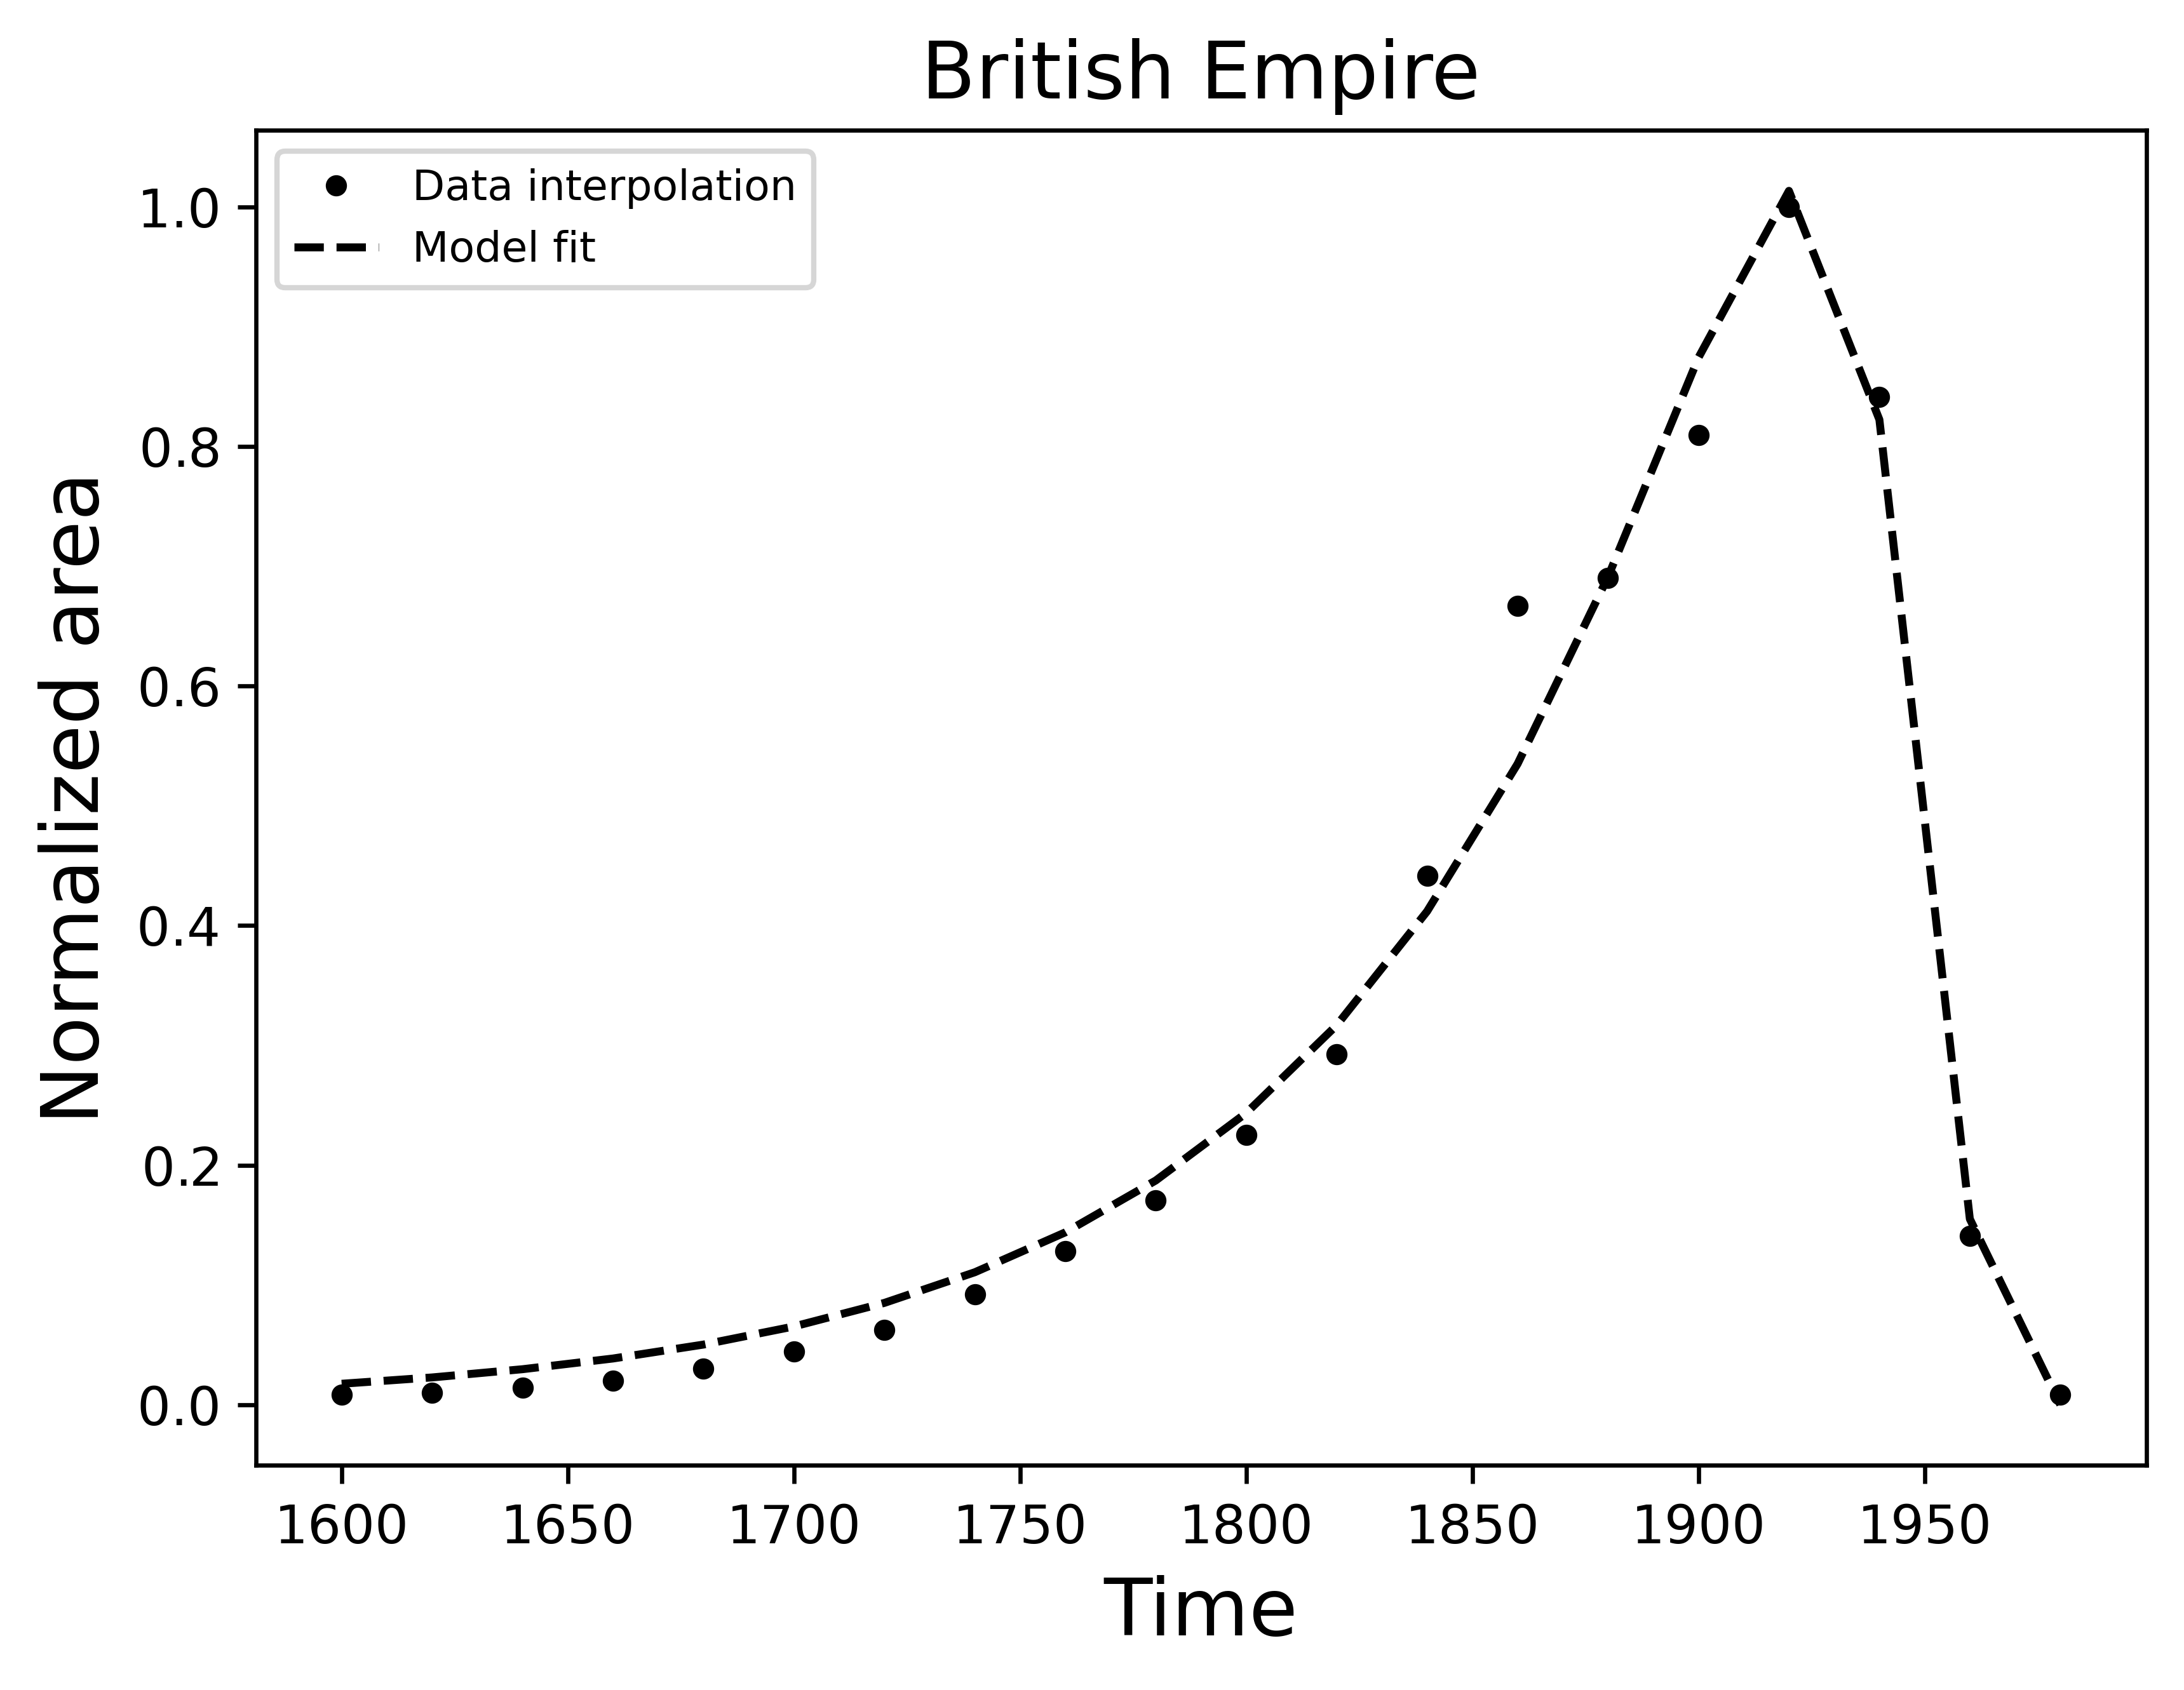

In [2]:
x0_bri = [1.017e+00, 1.866e-01, 7.046e-02, 1.923e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=1,
    x0=x0_bri,
    save=True
)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.1091870365944354
        x: [ 1.129e+00  5.923e-01  5.238e-02  1.933e+03]
      nit: 22
      jac: [ 1.134e-06 -5.867e-08  1.098e-06 -2.701e-08]
 hess_inv: [[ 5.914e-01 -1.052e+00  7.350e-02  1.144e+01]
            [-1.052e+00  2.817e+01 -1.508e+00 -2.251e+02]
            [ 7.350e-02 -1.508e+00  8.255e-02  1.232e+01]
            [ 1.144e+01 -2.251e+02  1.232e+01  2.192e+03]]
     nfev: 125
     njev: 25


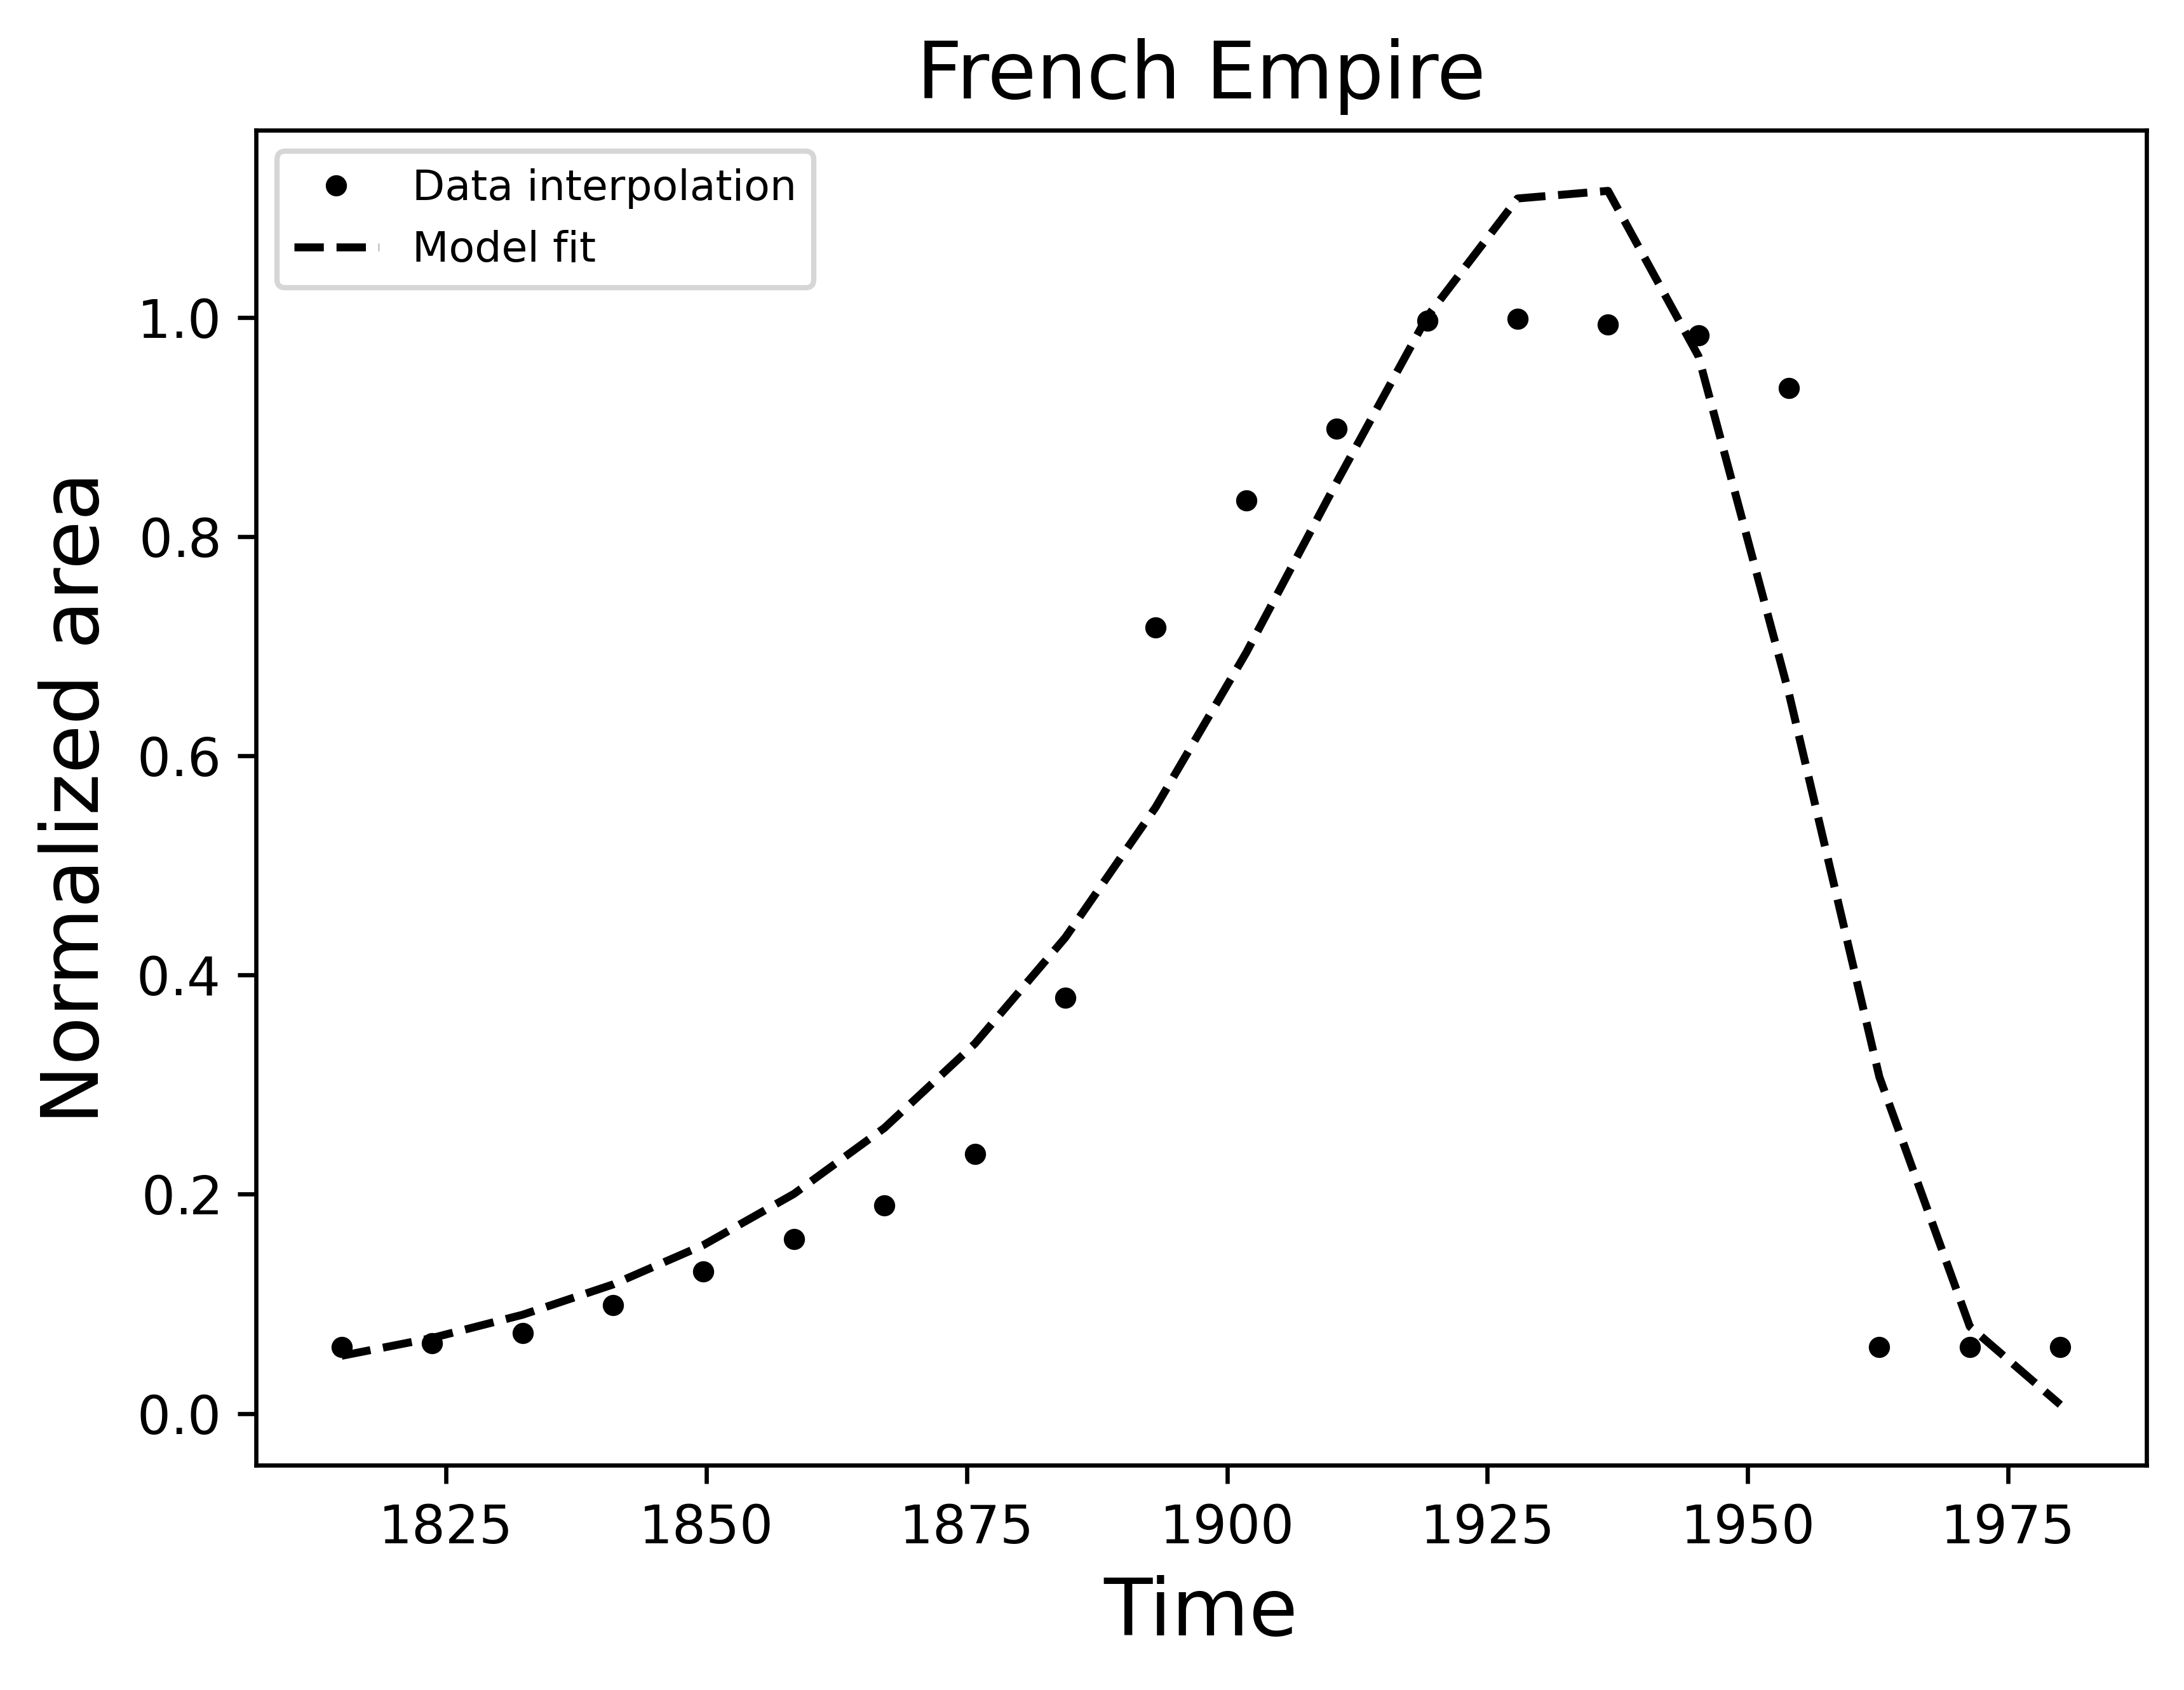

In [3]:
x0_fre = [1.129e+00, 5.868e-01, 5.270e-02, 1.933e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=2,
    x0=x0_fre,
    save=True
)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0560450113173558
        x: [ 1.062e+00  2.907e-01  3.037e-02  1.768e+03]
      nit: 33
      jac: [ 9.416e-07  4.605e-07  1.674e-06 -1.397e-09]
 hess_inv: [[ 3.981e-01 -2.742e-01  2.779e-02  2.146e+01]
            [-2.742e-01  2.382e+00 -1.675e-01 -1.240e+02]
            [ 2.779e-02 -1.675e-01  1.229e-02  9.134e+00]
            [ 2.146e+01 -1.240e+02  9.134e+00  8.297e+03]]
     nfev: 205
     njev: 41


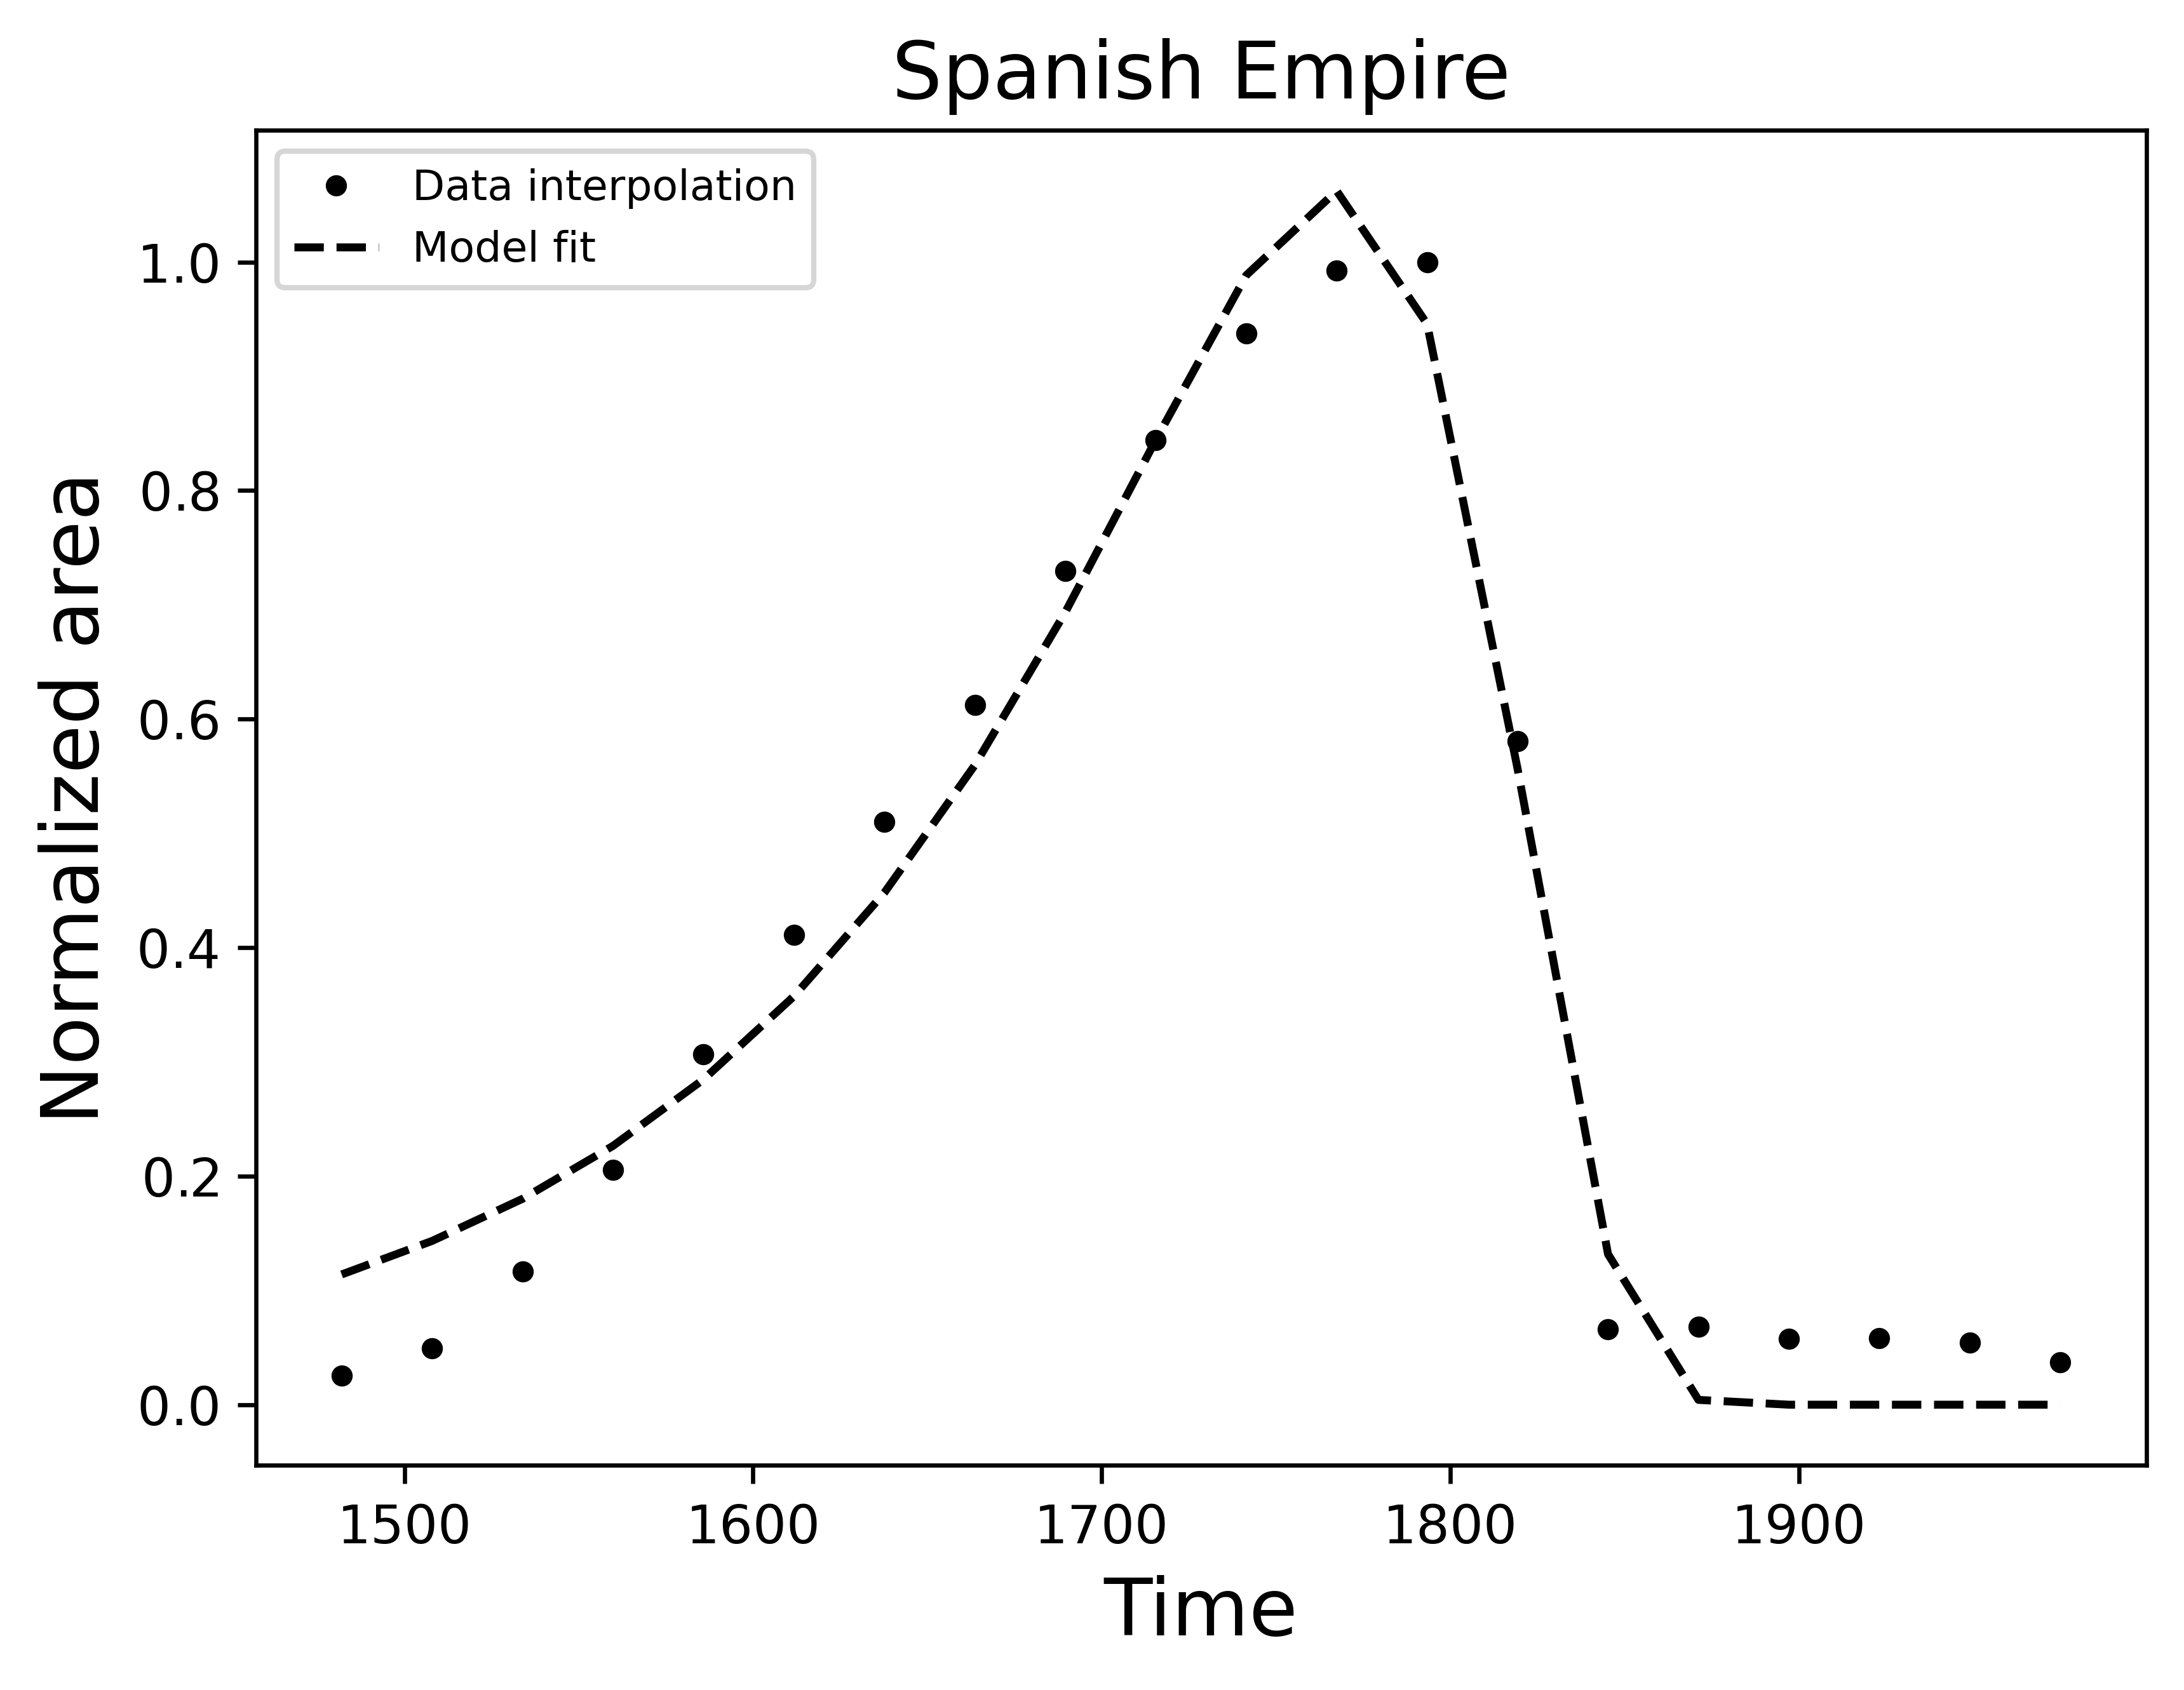

In [4]:
x0_spa = [1,  1,  1e-2,  1.768e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=3,
    x0=x0_spa,
    save=True
)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.03367197661753442
        x: [ 9.184e-01  1.629e+00  1.104e-02  1.823e+03]
      nit: 24
      jac: [ 4.238e-08 -9.779e-09 -3.803e-06  0.000e+00]
 hess_inv: [[ 3.461e-01 -5.916e-01  5.277e-03  4.915e+00]
            [-5.916e-01  2.081e+02 -7.577e-01 -8.306e+02]
            [ 5.277e-03 -7.577e-01  2.837e-03  3.093e+00]
            [ 4.915e+00 -8.306e+02  3.093e+00  5.802e+03]]
     nfev: 155
     njev: 31


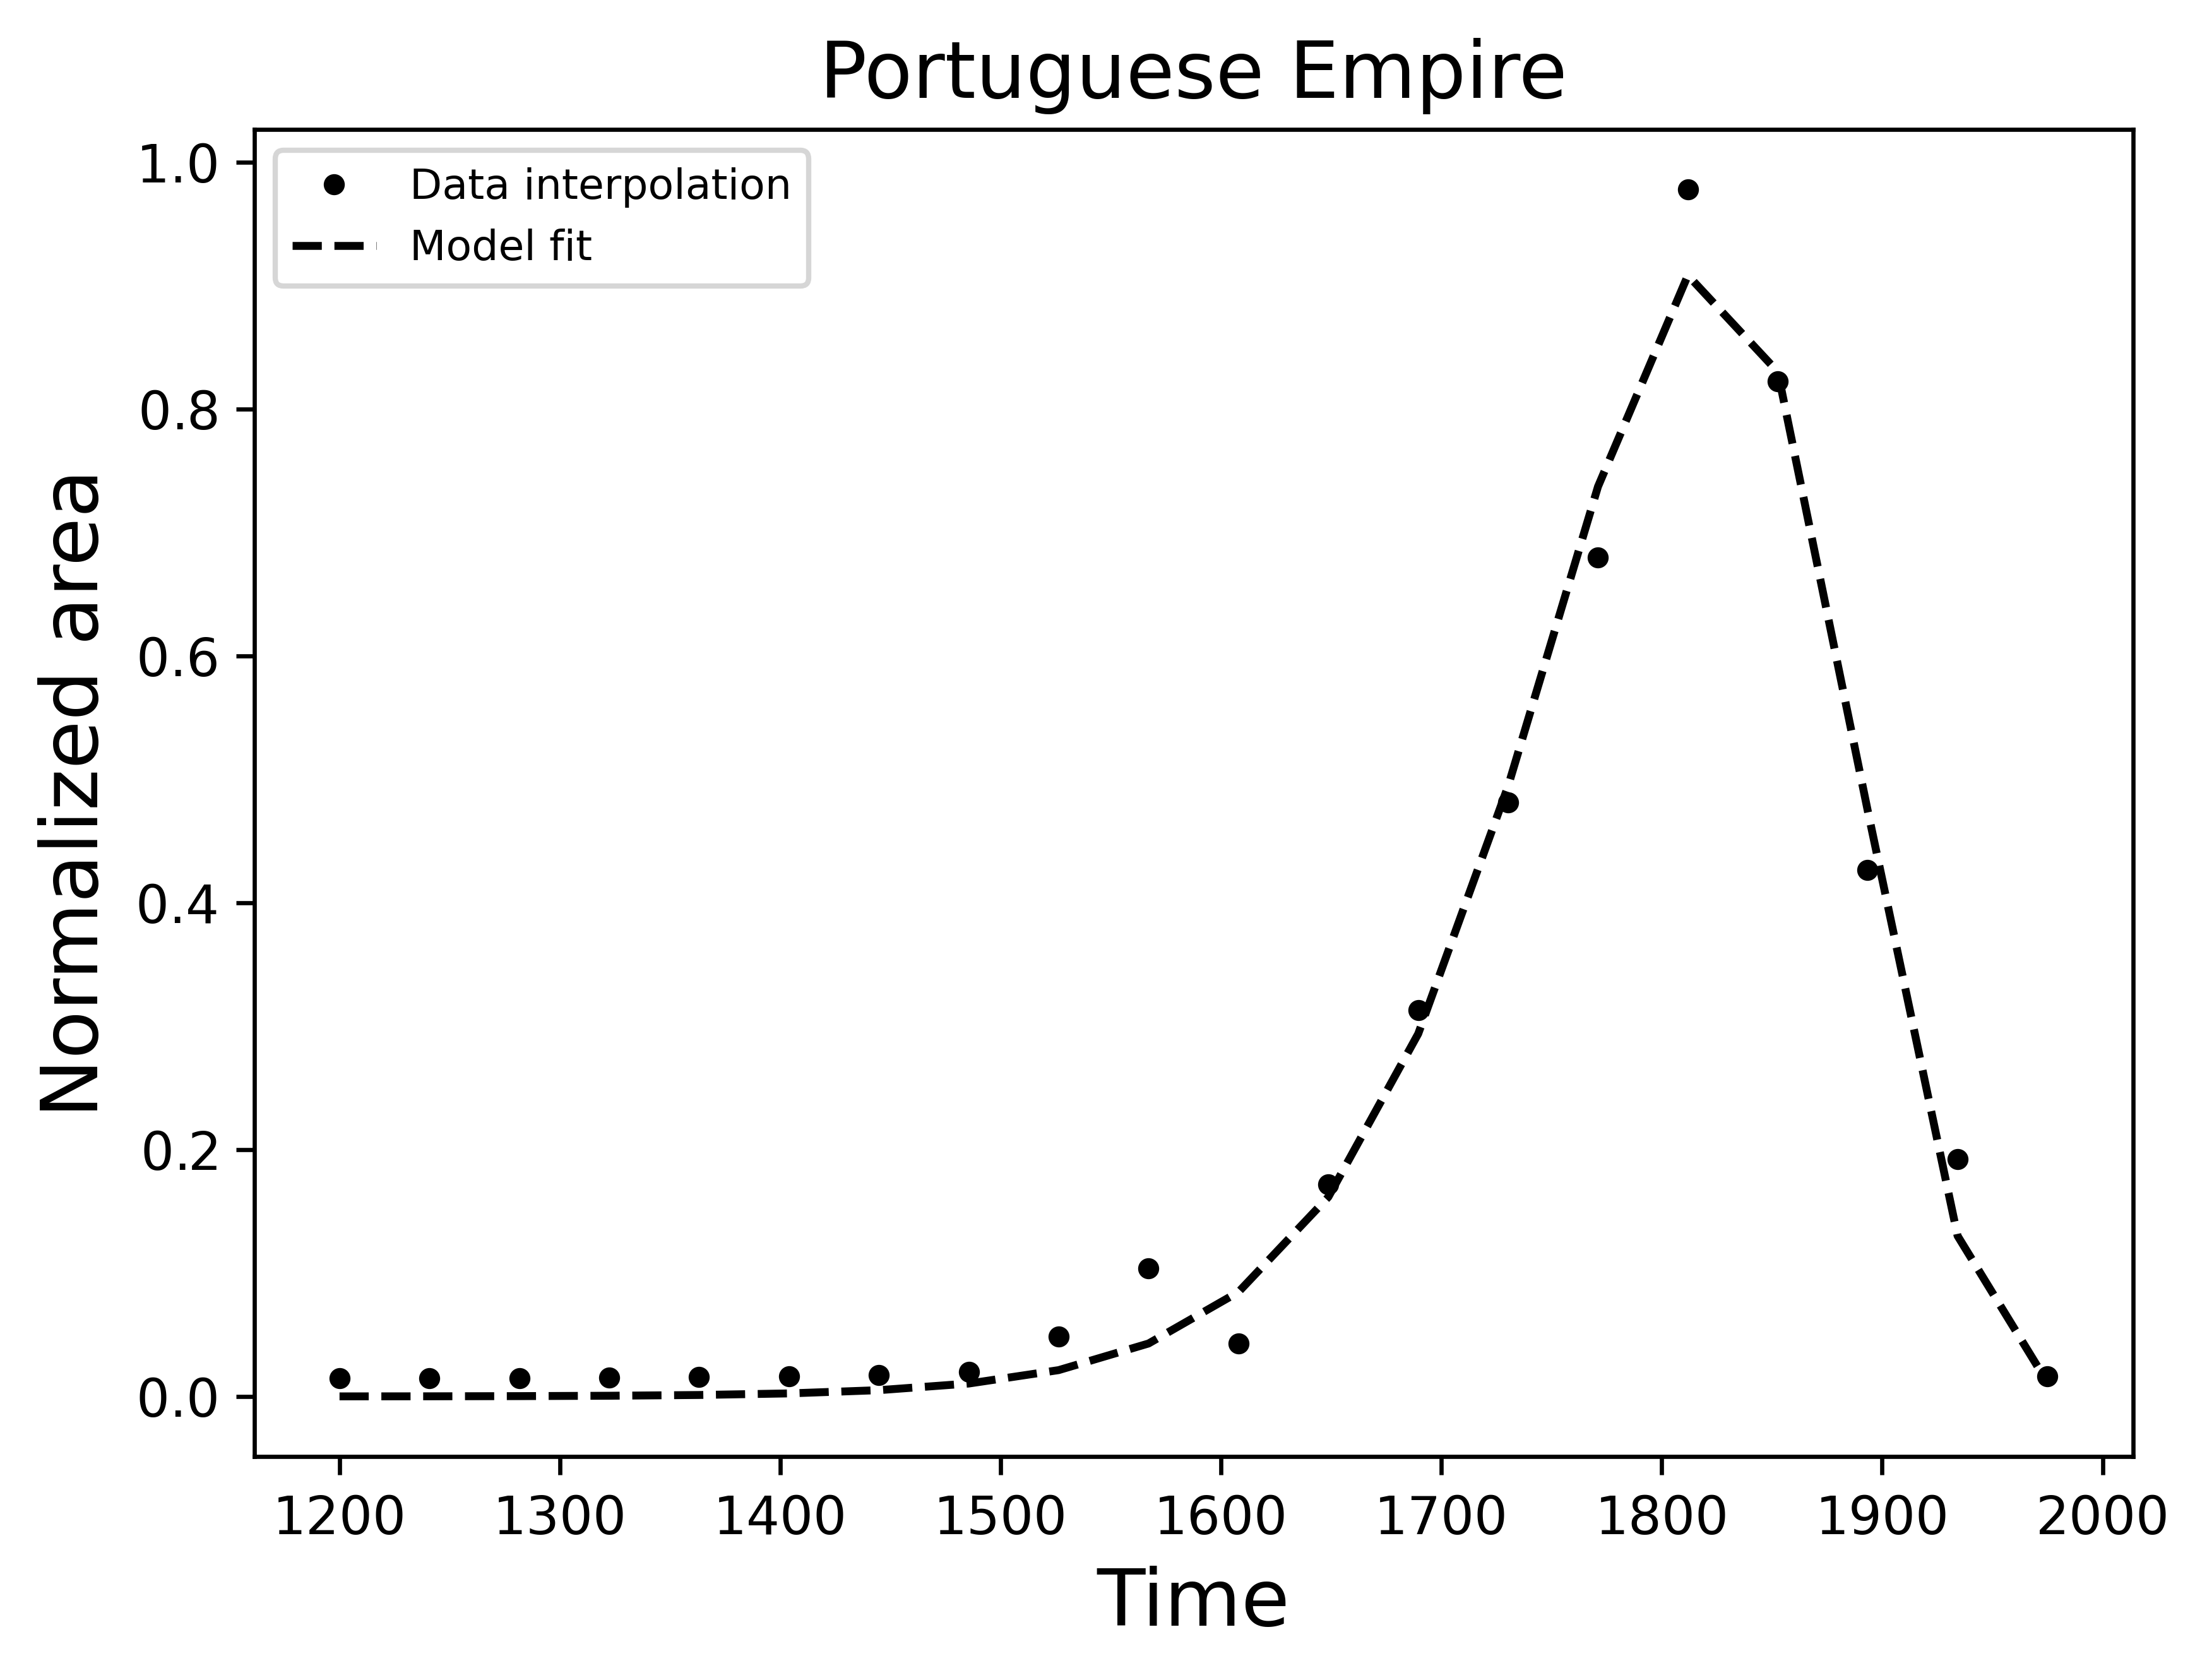

In [5]:
x0_por = [9.184e-01,  1.629e+00,  1.104e-02,  1.823e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=4,
    x0=x0_por,
    save=True
)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.1016130974965433
        x: [ 1.080e+00  6.357e-01  1.548e-02  1.824e+03]
      nit: 46
      jac: [-2.893e-06  3.304e-06  2.586e-04  5.588e-09]
 hess_inv: [[ 3.467e-01 -1.306e-01  5.426e-03  1.044e+01]
            [-1.306e-01  2.664e+01 -3.604e-01 -5.997e+02]
            [ 5.426e-03 -3.604e-01  4.999e-03  8.355e+00]
            [ 1.044e+01 -5.997e+02  8.355e+00  1.656e+04]]
     nfev: 457
     njev: 89


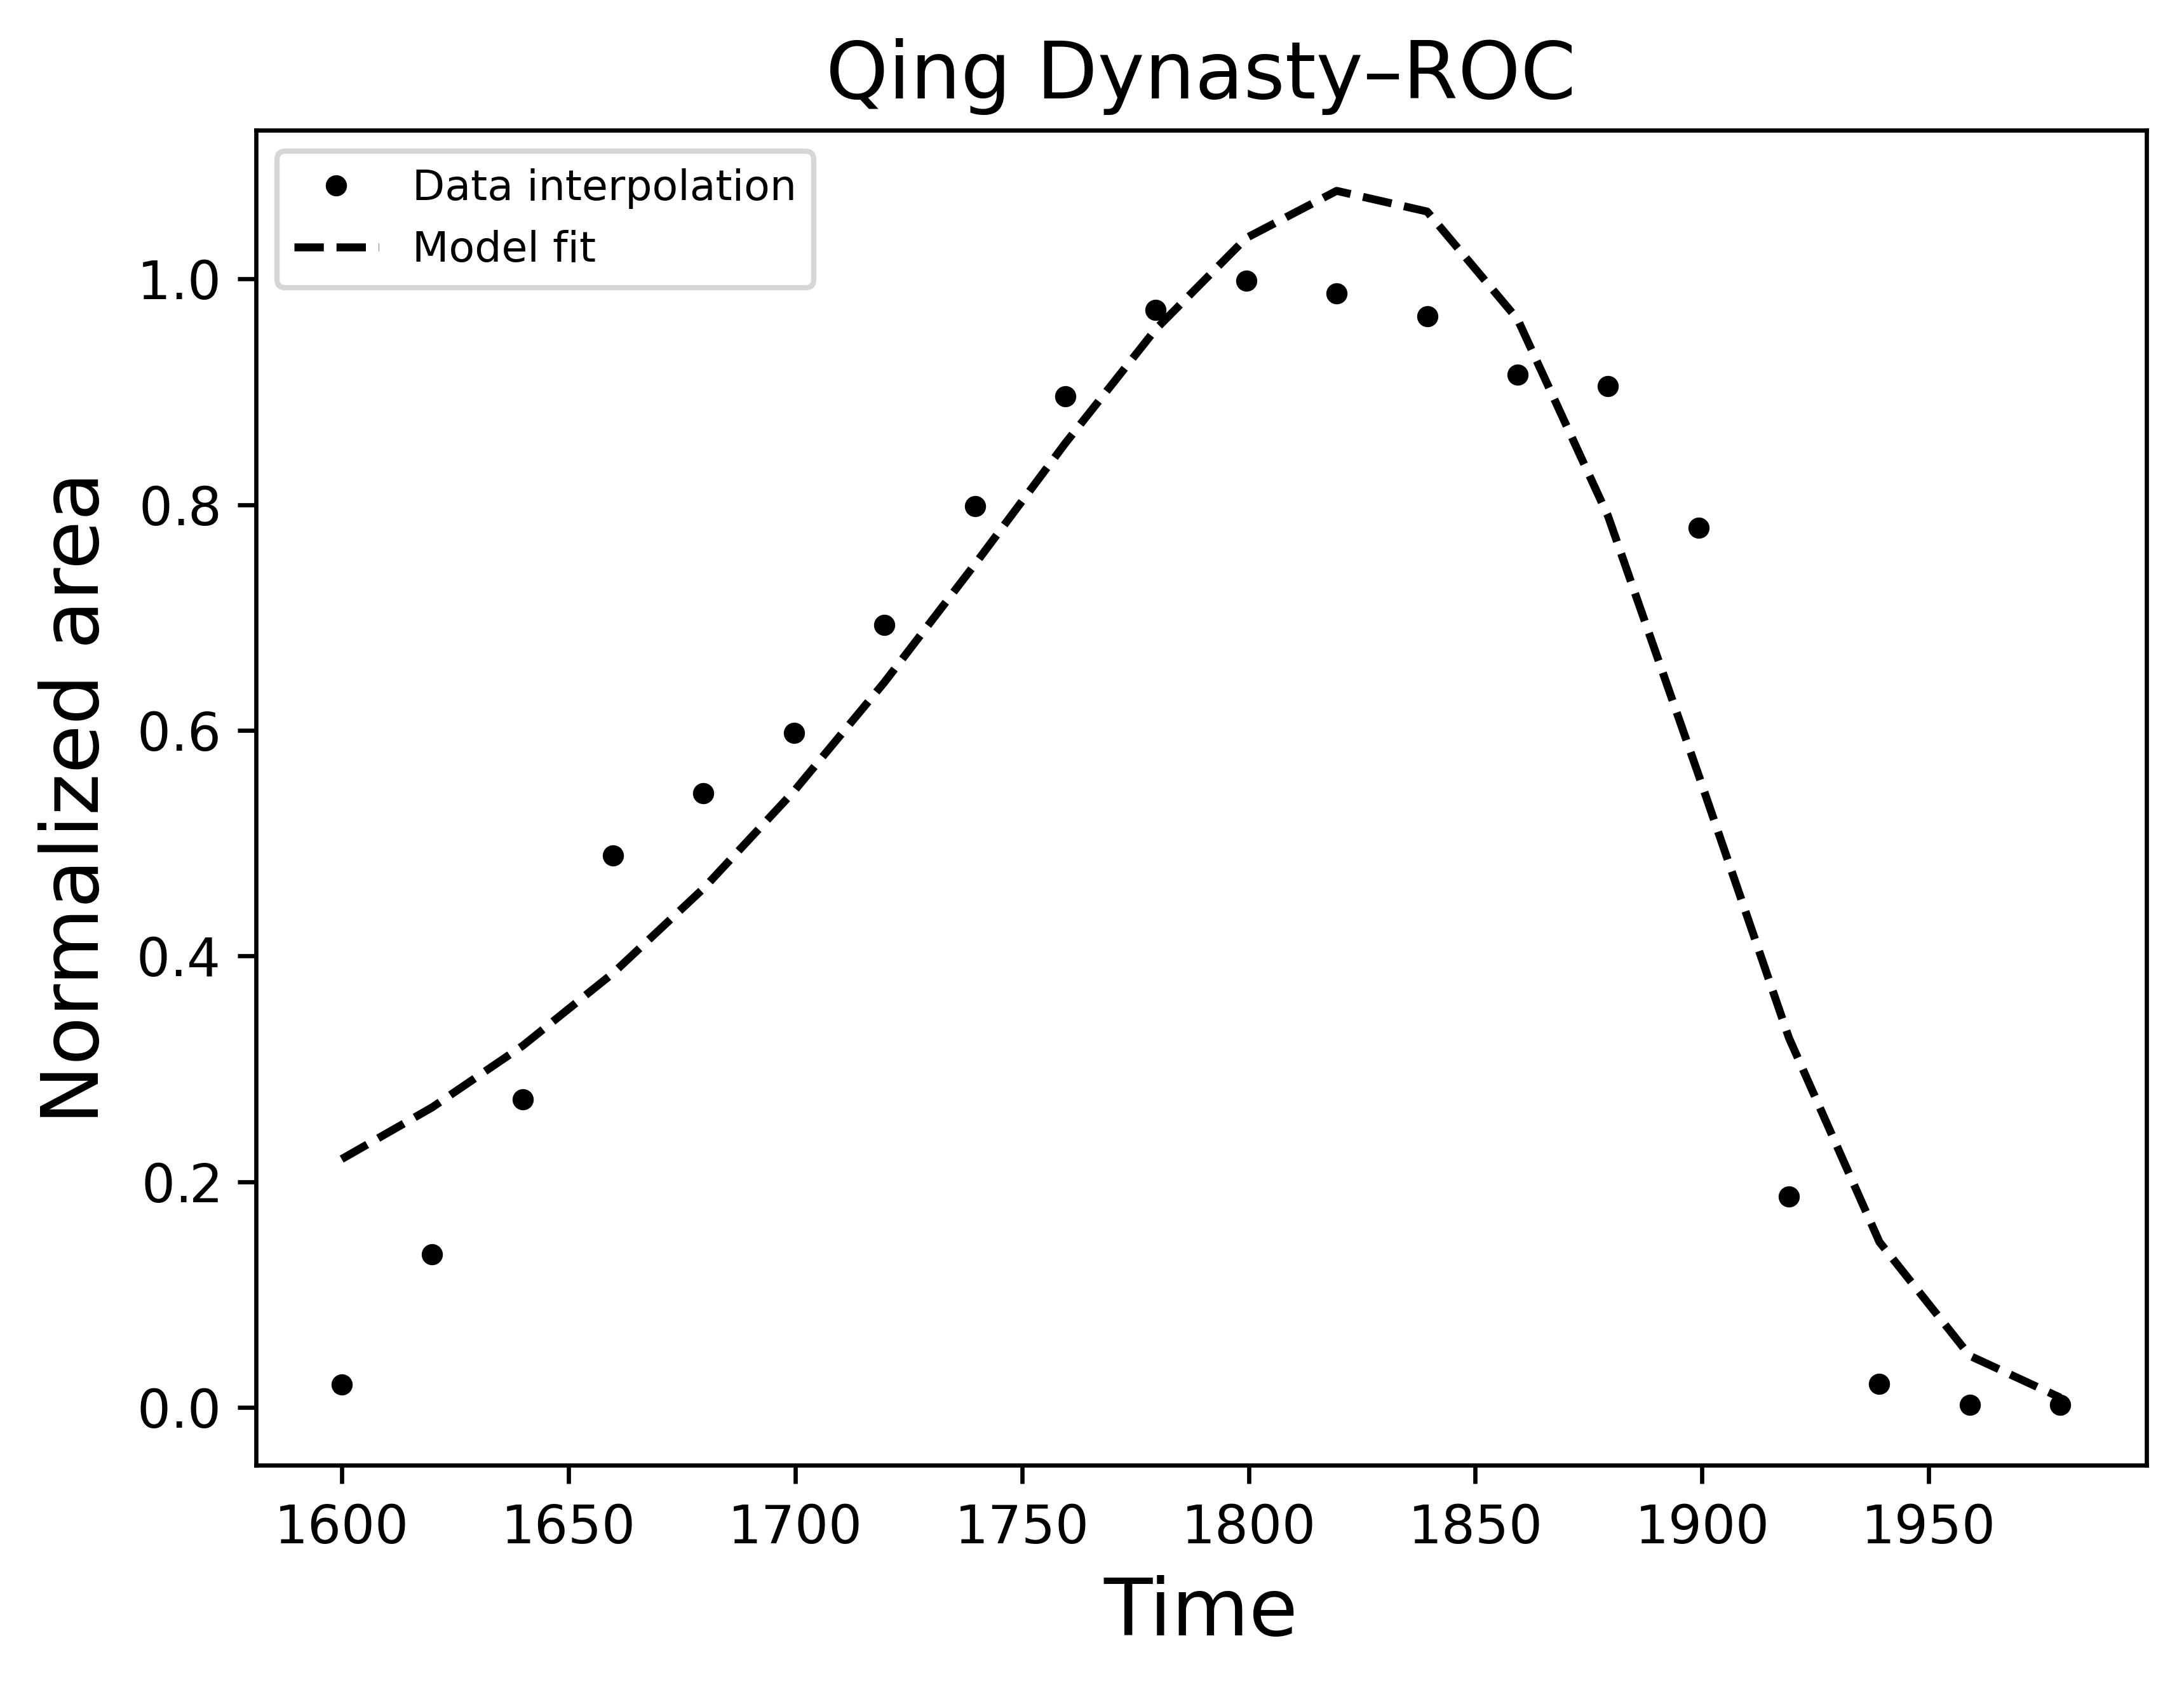

In [6]:
x0_qing = [1.044e+00,  2.831e+00,  6.465e-03, 1.812e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=5,
    x0=x0_qing,
    save=True
)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.06590110637886984
        x: [ 1.029e+00  2.437e+01  4.261e-03  1.292e+03]
      nit: 51
      jac: [ 7.130e-06 -3.716e-07 -2.959e-03 -1.565e-07]
 hess_inv: [[ 2.316e-01  2.505e+00  4.471e-04 -5.581e-01]
            [ 2.505e+00  7.877e+04 -6.535e+00 -3.683e+03]
            [ 4.471e-04 -6.535e+00  5.449e-04  3.081e-01]
            [-5.581e-01 -3.683e+03  3.081e-01  6.321e+02]]
     nfev: 557
     njev: 109


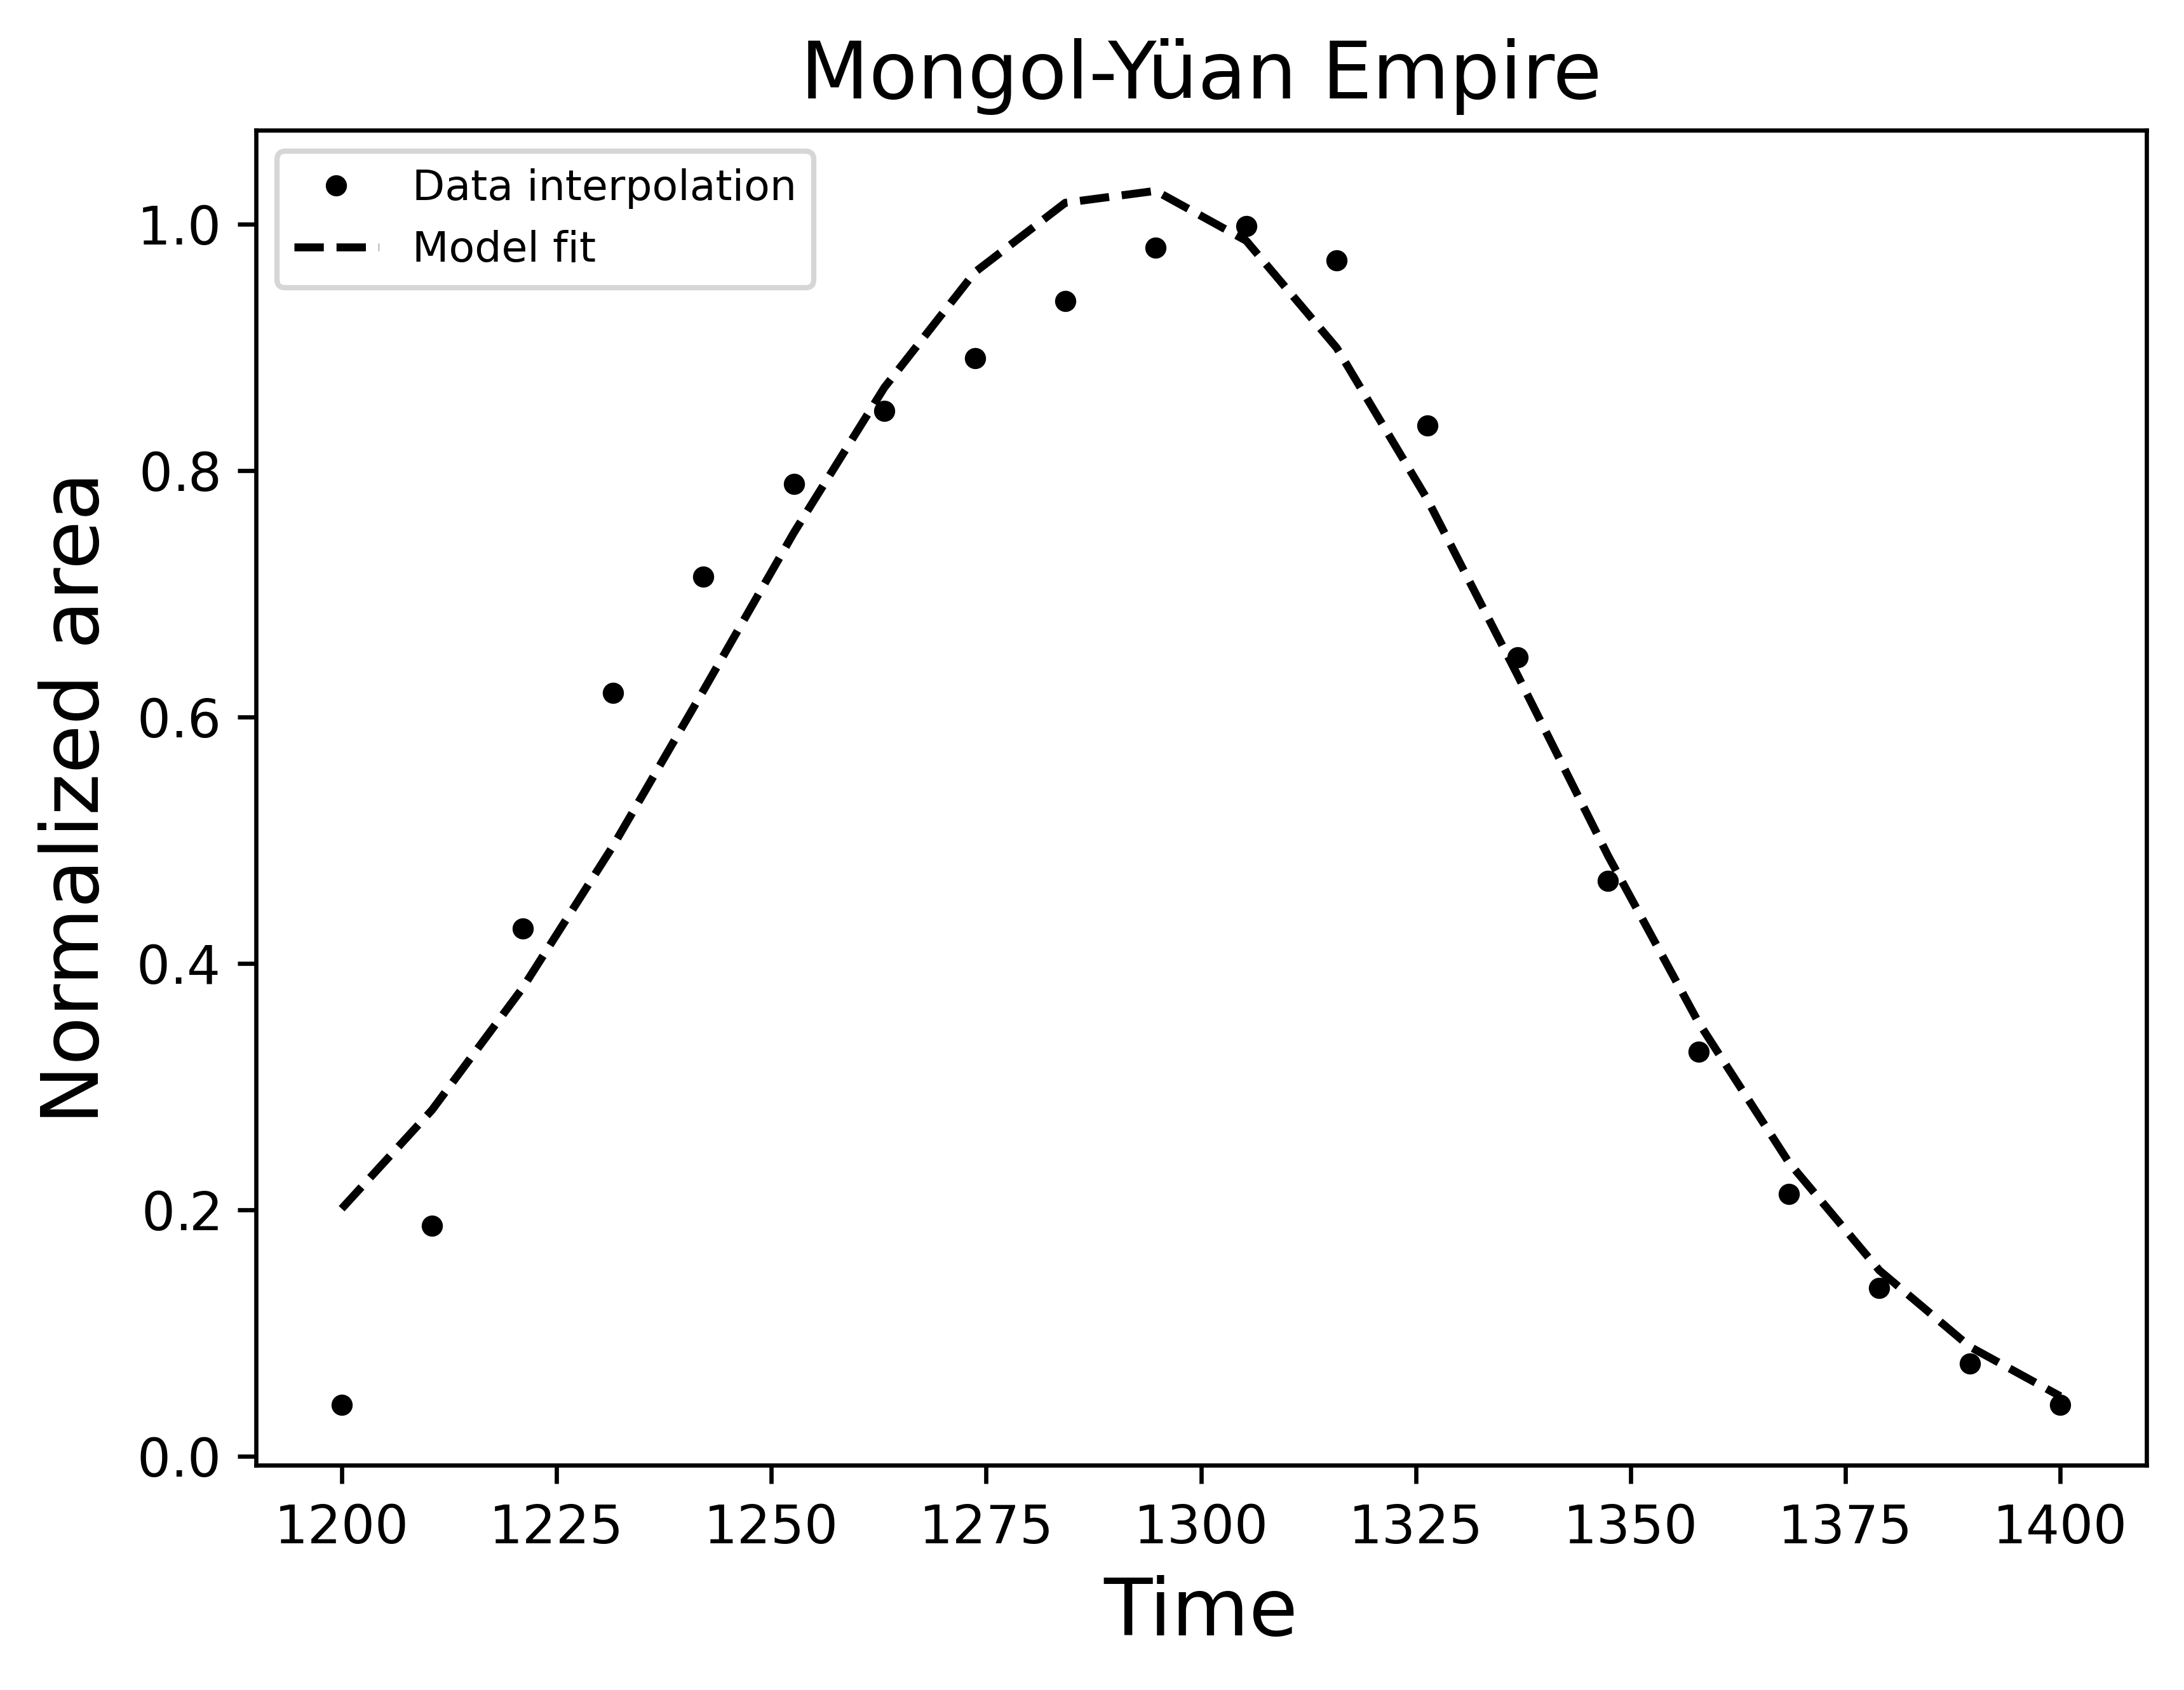

In [7]:
x0_mon = [1.031e+00,  1.887e+01,  4.858e-03,  1.292e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=6,
    x0=x0_mon,
    save=True
)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.06552541149528335
        x: [ 1.024e+00  7.026e+02  5.272e-04  7.472e+02]
      nit: 147
      jac: [-3.800e-04  7.823e-07  1.883e+00  1.554e-05]
 hess_inv: [[ 2.132e-01 -1.578e+01  8.003e-05  7.173e-01]
            [-1.578e+01  1.128e+07 -4.135e+00  1.242e+02]
            [ 8.003e-05 -4.135e+00  1.598e-06 -1.018e-03]
            [ 7.173e-01  1.242e+02 -1.018e-03  1.841e+03]]
     nfev: 1377
     njev: 273


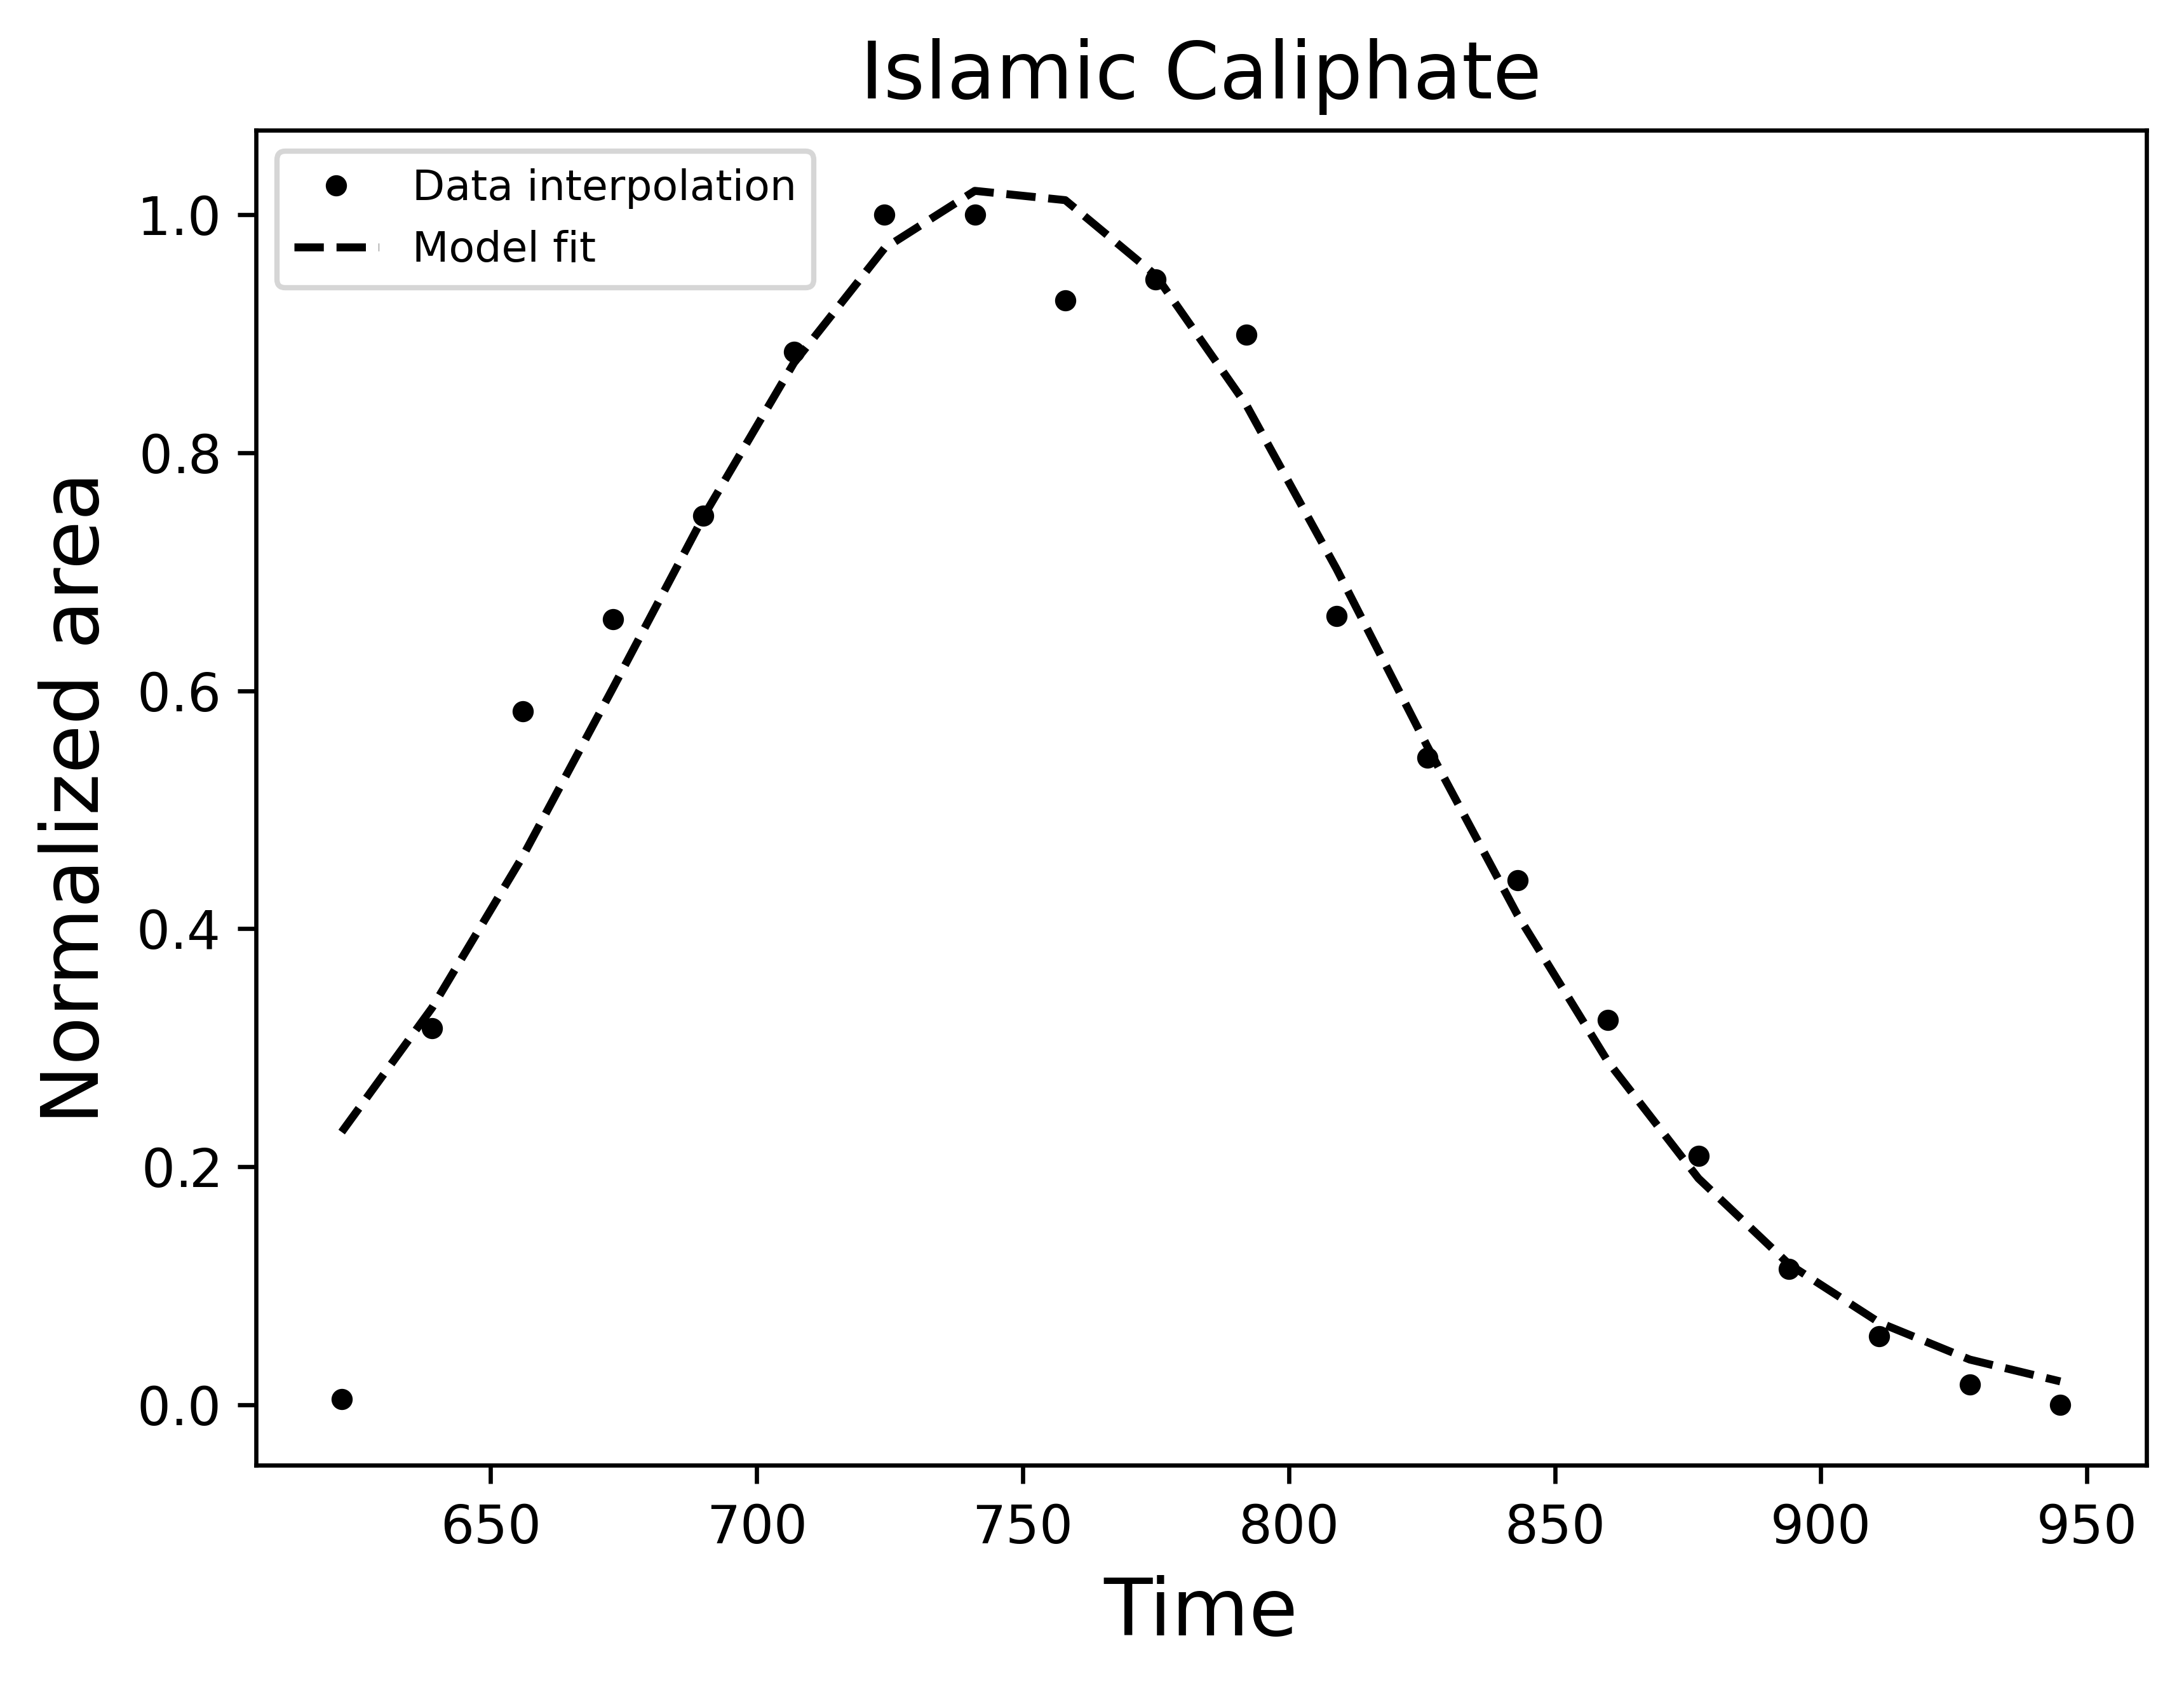

In [8]:
x0_cal = [1,  2e1,  5e-2,  750]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=7,
    x0=x0_cal,
    save=True
)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.10903860673101809
        x: [ 1.096e+00  6.485e+02  9.978e-04  1.092e+03]
      nit: 19
      jac: [ 6.172e-06 -5.905e-07 -2.105e-04 -6.892e-08]
 hess_inv: [[ 6.346e-01 -2.726e-02  3.486e-04 -1.525e-01]
            [-2.726e-02  1.005e+00 -1.527e-05  2.568e-01]
            [ 3.486e-04 -1.527e-05  5.580e-07 -9.655e-05]
            [-1.525e-01  2.568e-01 -9.655e-05  2.770e+01]]
     nfev: 309
     njev: 60


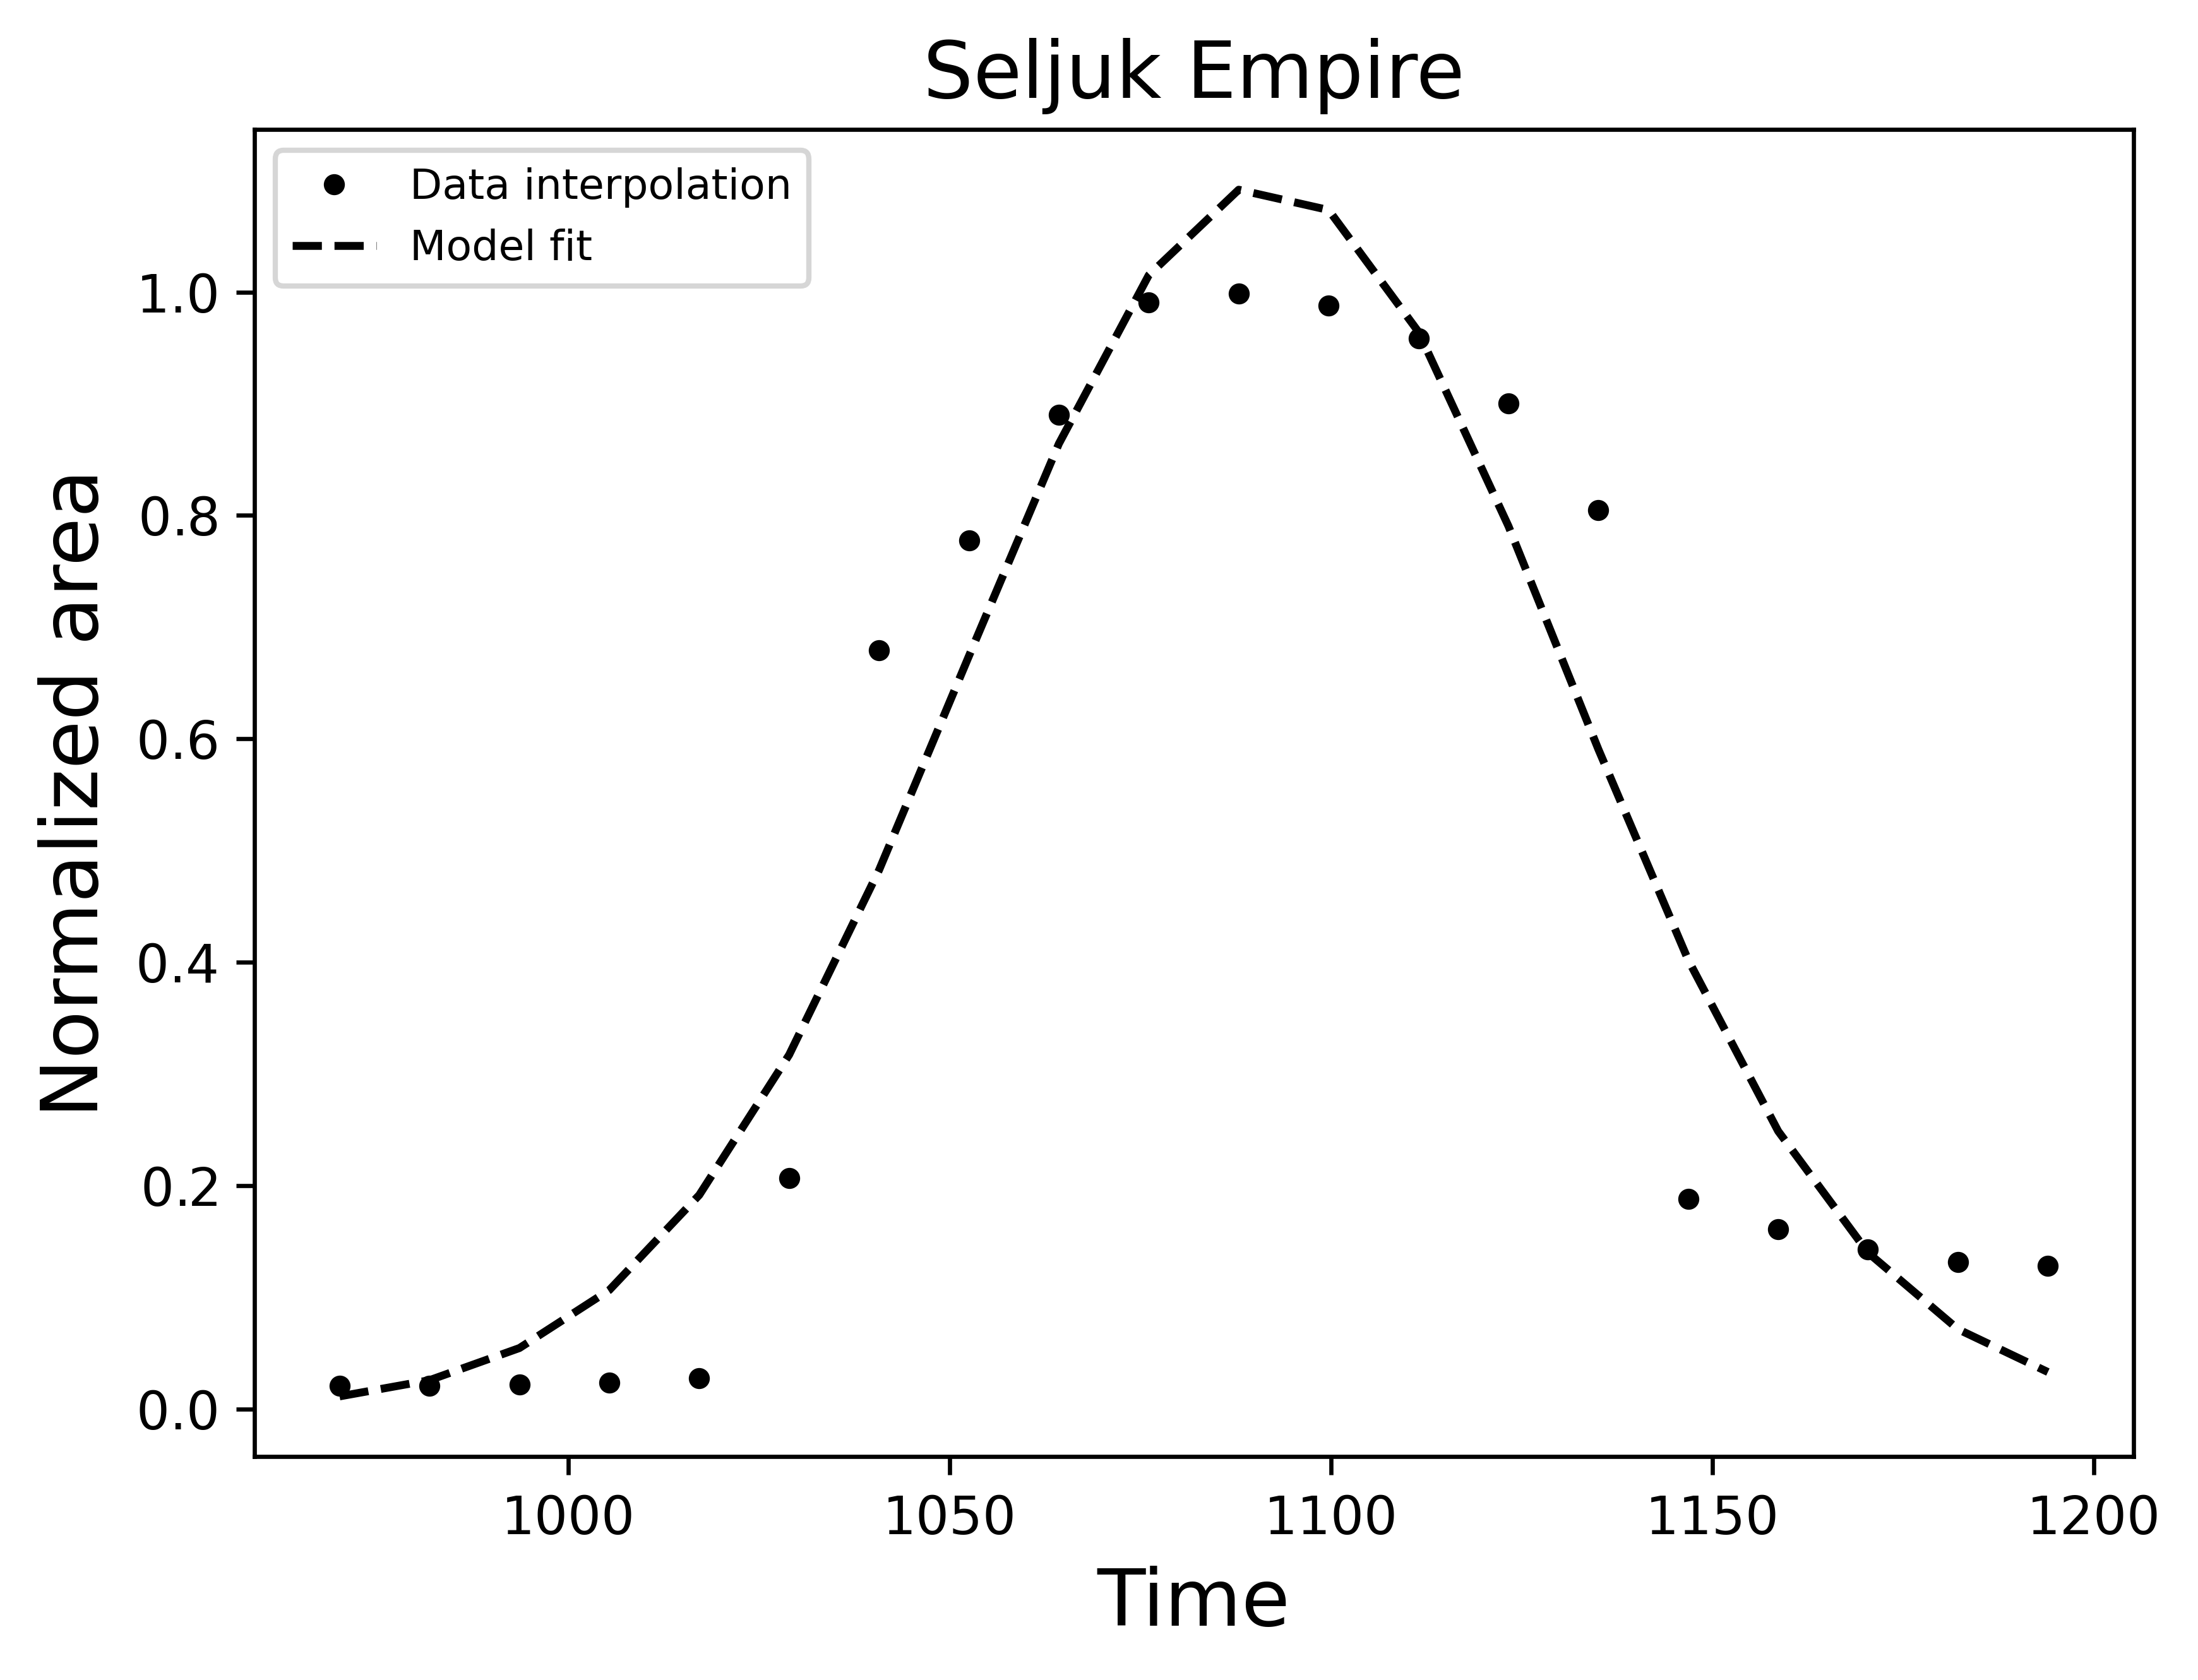

In [9]:
x0_sel = [1.088e+00,  6.485e+02,  9.858e-04,  1.092e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=8,
    x0=x0_sel,
    save=True
)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.06615879355399205
        x: [ 1.053e+00  5.812e+02  2.351e-02  1.942e+03]
      nit: 10
      jac: [ 1.779e-07  3.800e-07 -8.633e-07 -1.276e-07]
 hess_inv: [[ 4.396e-01  1.208e-03  6.572e-03 -5.850e-03]
            [ 1.208e-03  1.001e+00  3.209e-05  2.473e-03]
            [ 6.572e-03  3.209e-05  2.947e-04 -1.511e-04]
            [-5.850e-03  2.473e-03 -1.511e-04  1.567e+00]]
     nfev: 75
     njev: 15


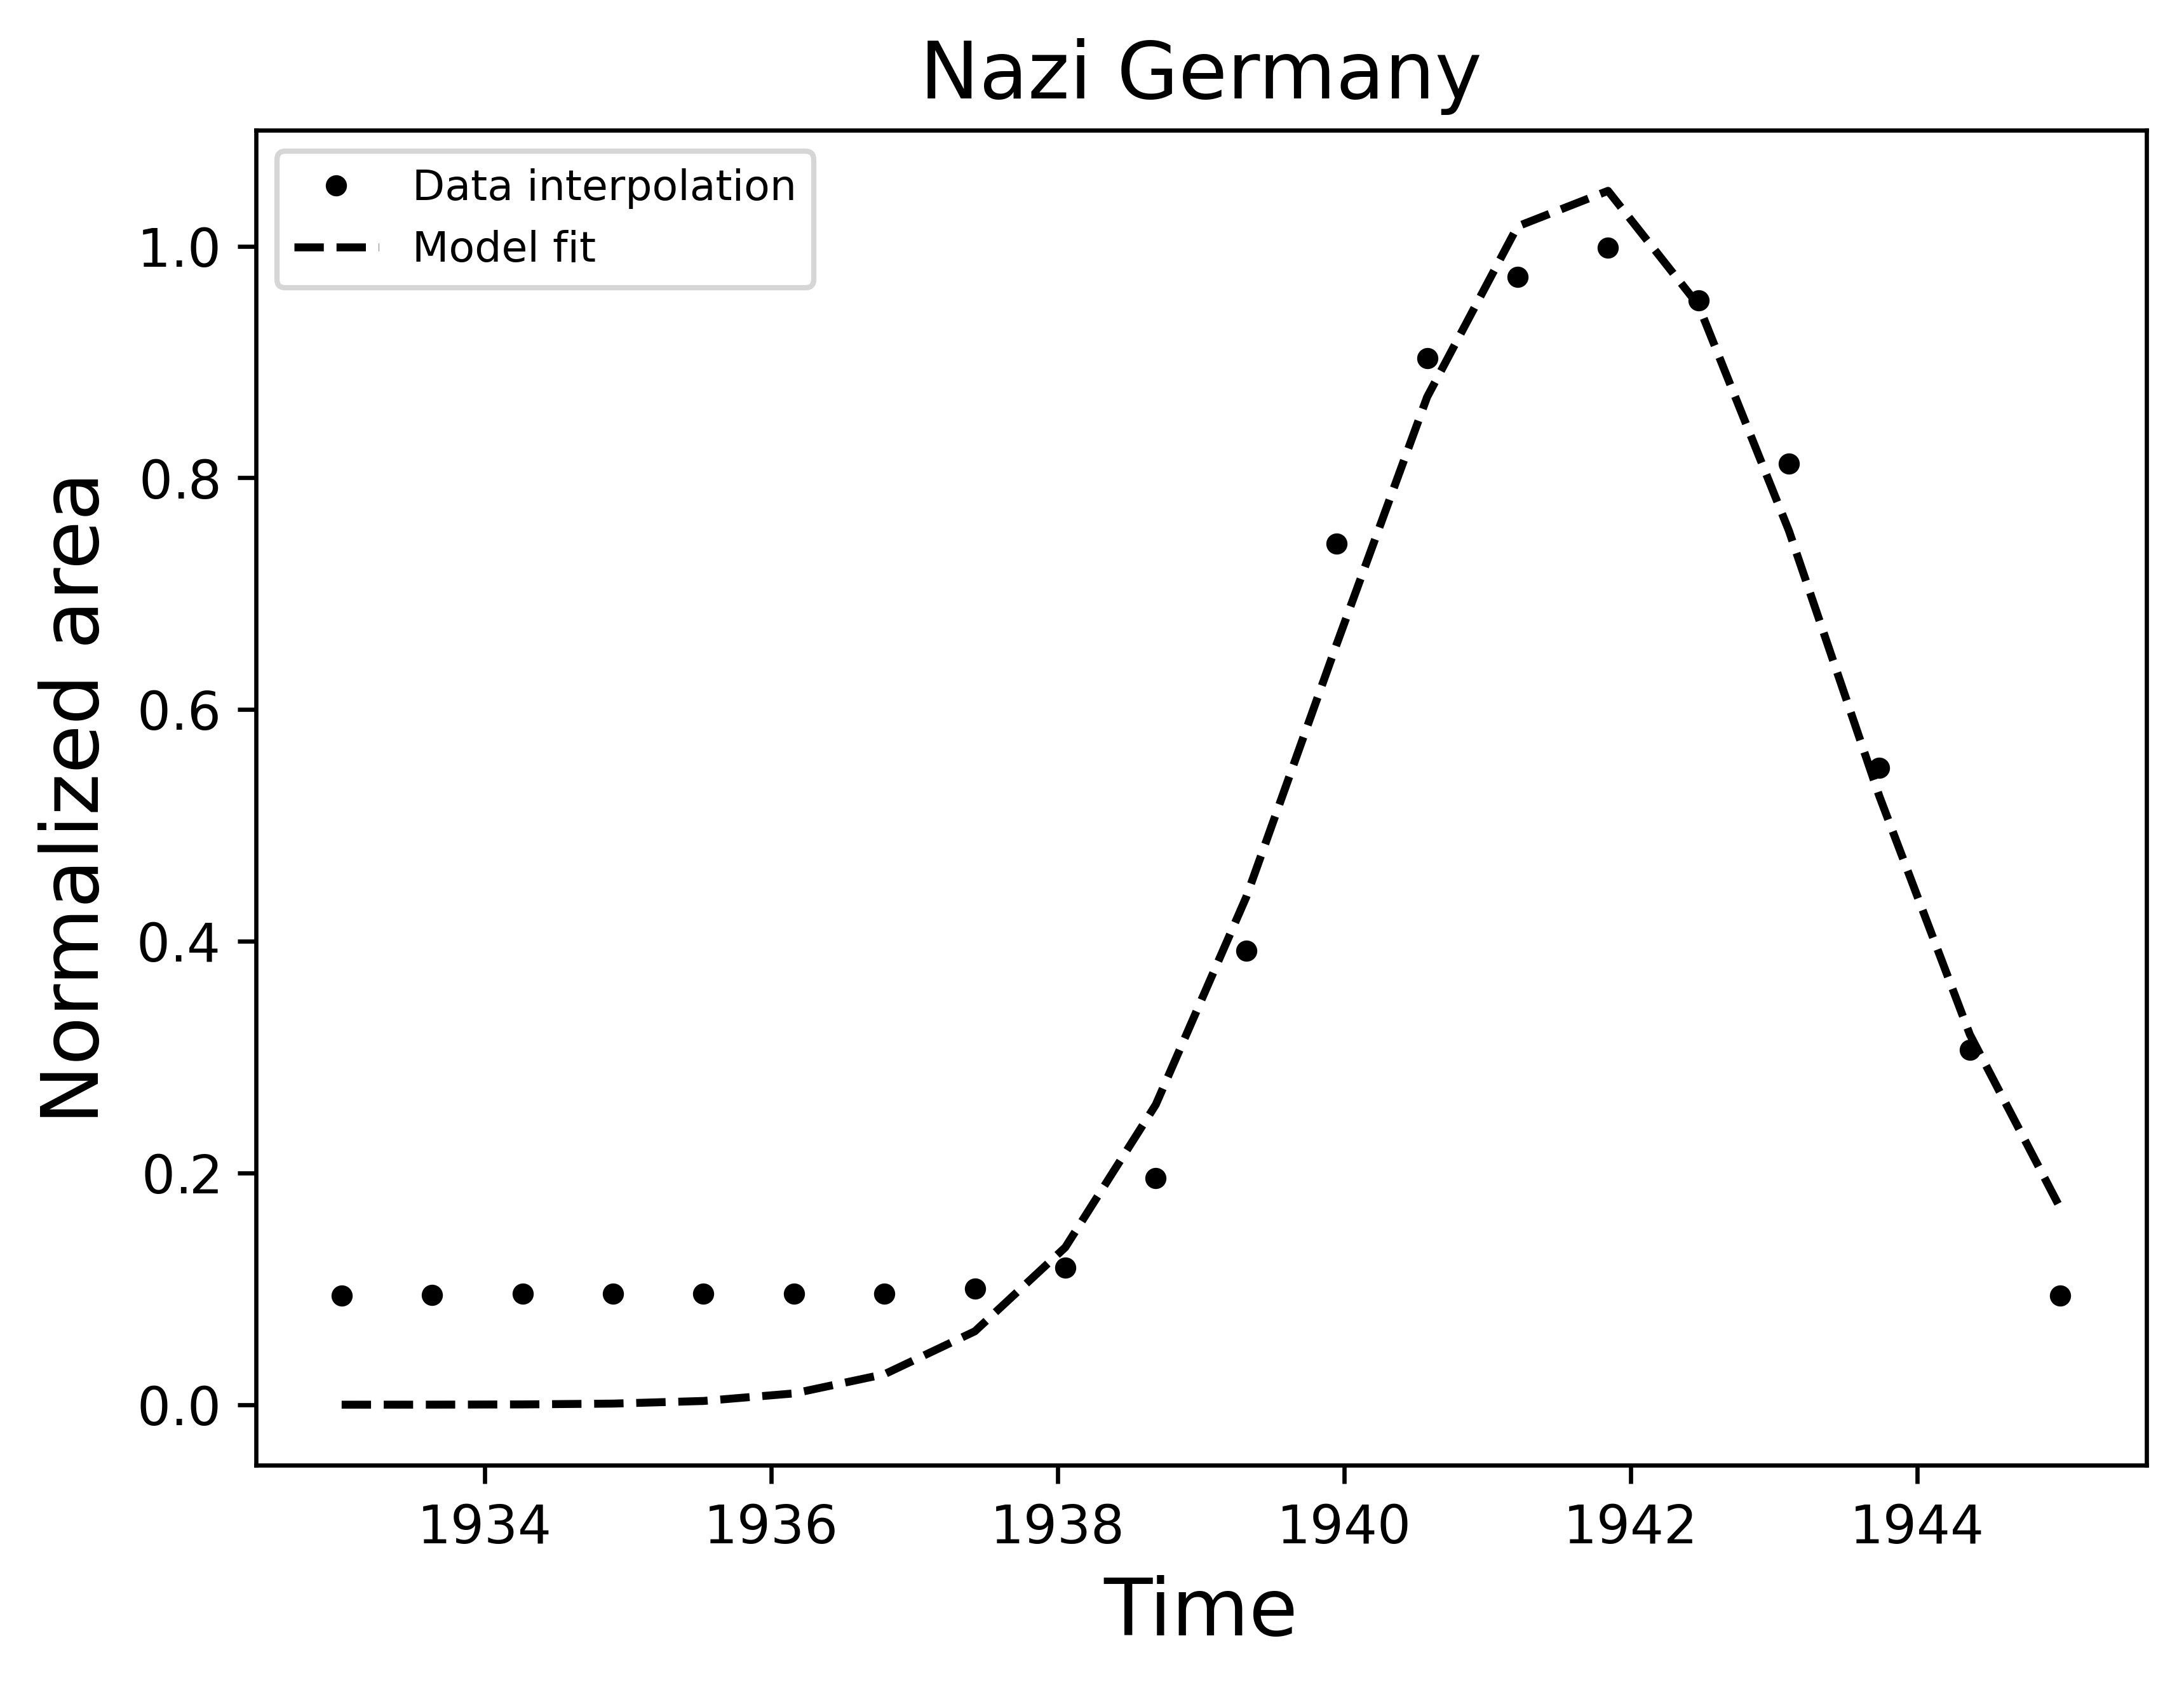

In [10]:
x0_ger = [1.075e+00, 5.812e+02, 2.609e-02, 1.942e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=9,
    x0=x0_ger,
    save=True
)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.041911253049972085
        x: [ 9.436e-01  9.968e-03  7.118e+00  1.944e+03]
      nit: 178
      jac: [ 3.203e-05 -2.905e-03 -6.378e-06  2.127e-05]
 hess_inv: [[ 4.071e+01 -7.752e+00  5.515e+03  4.948e+02]
            [-7.752e+00  1.490e+00 -1.059e+03 -9.502e+01]
            [ 5.515e+03 -1.059e+03  7.532e+05  6.756e+04]
            [ 4.948e+02 -9.502e+01  6.756e+04  6.060e+03]]
     nfev: 1297
     njev: 257


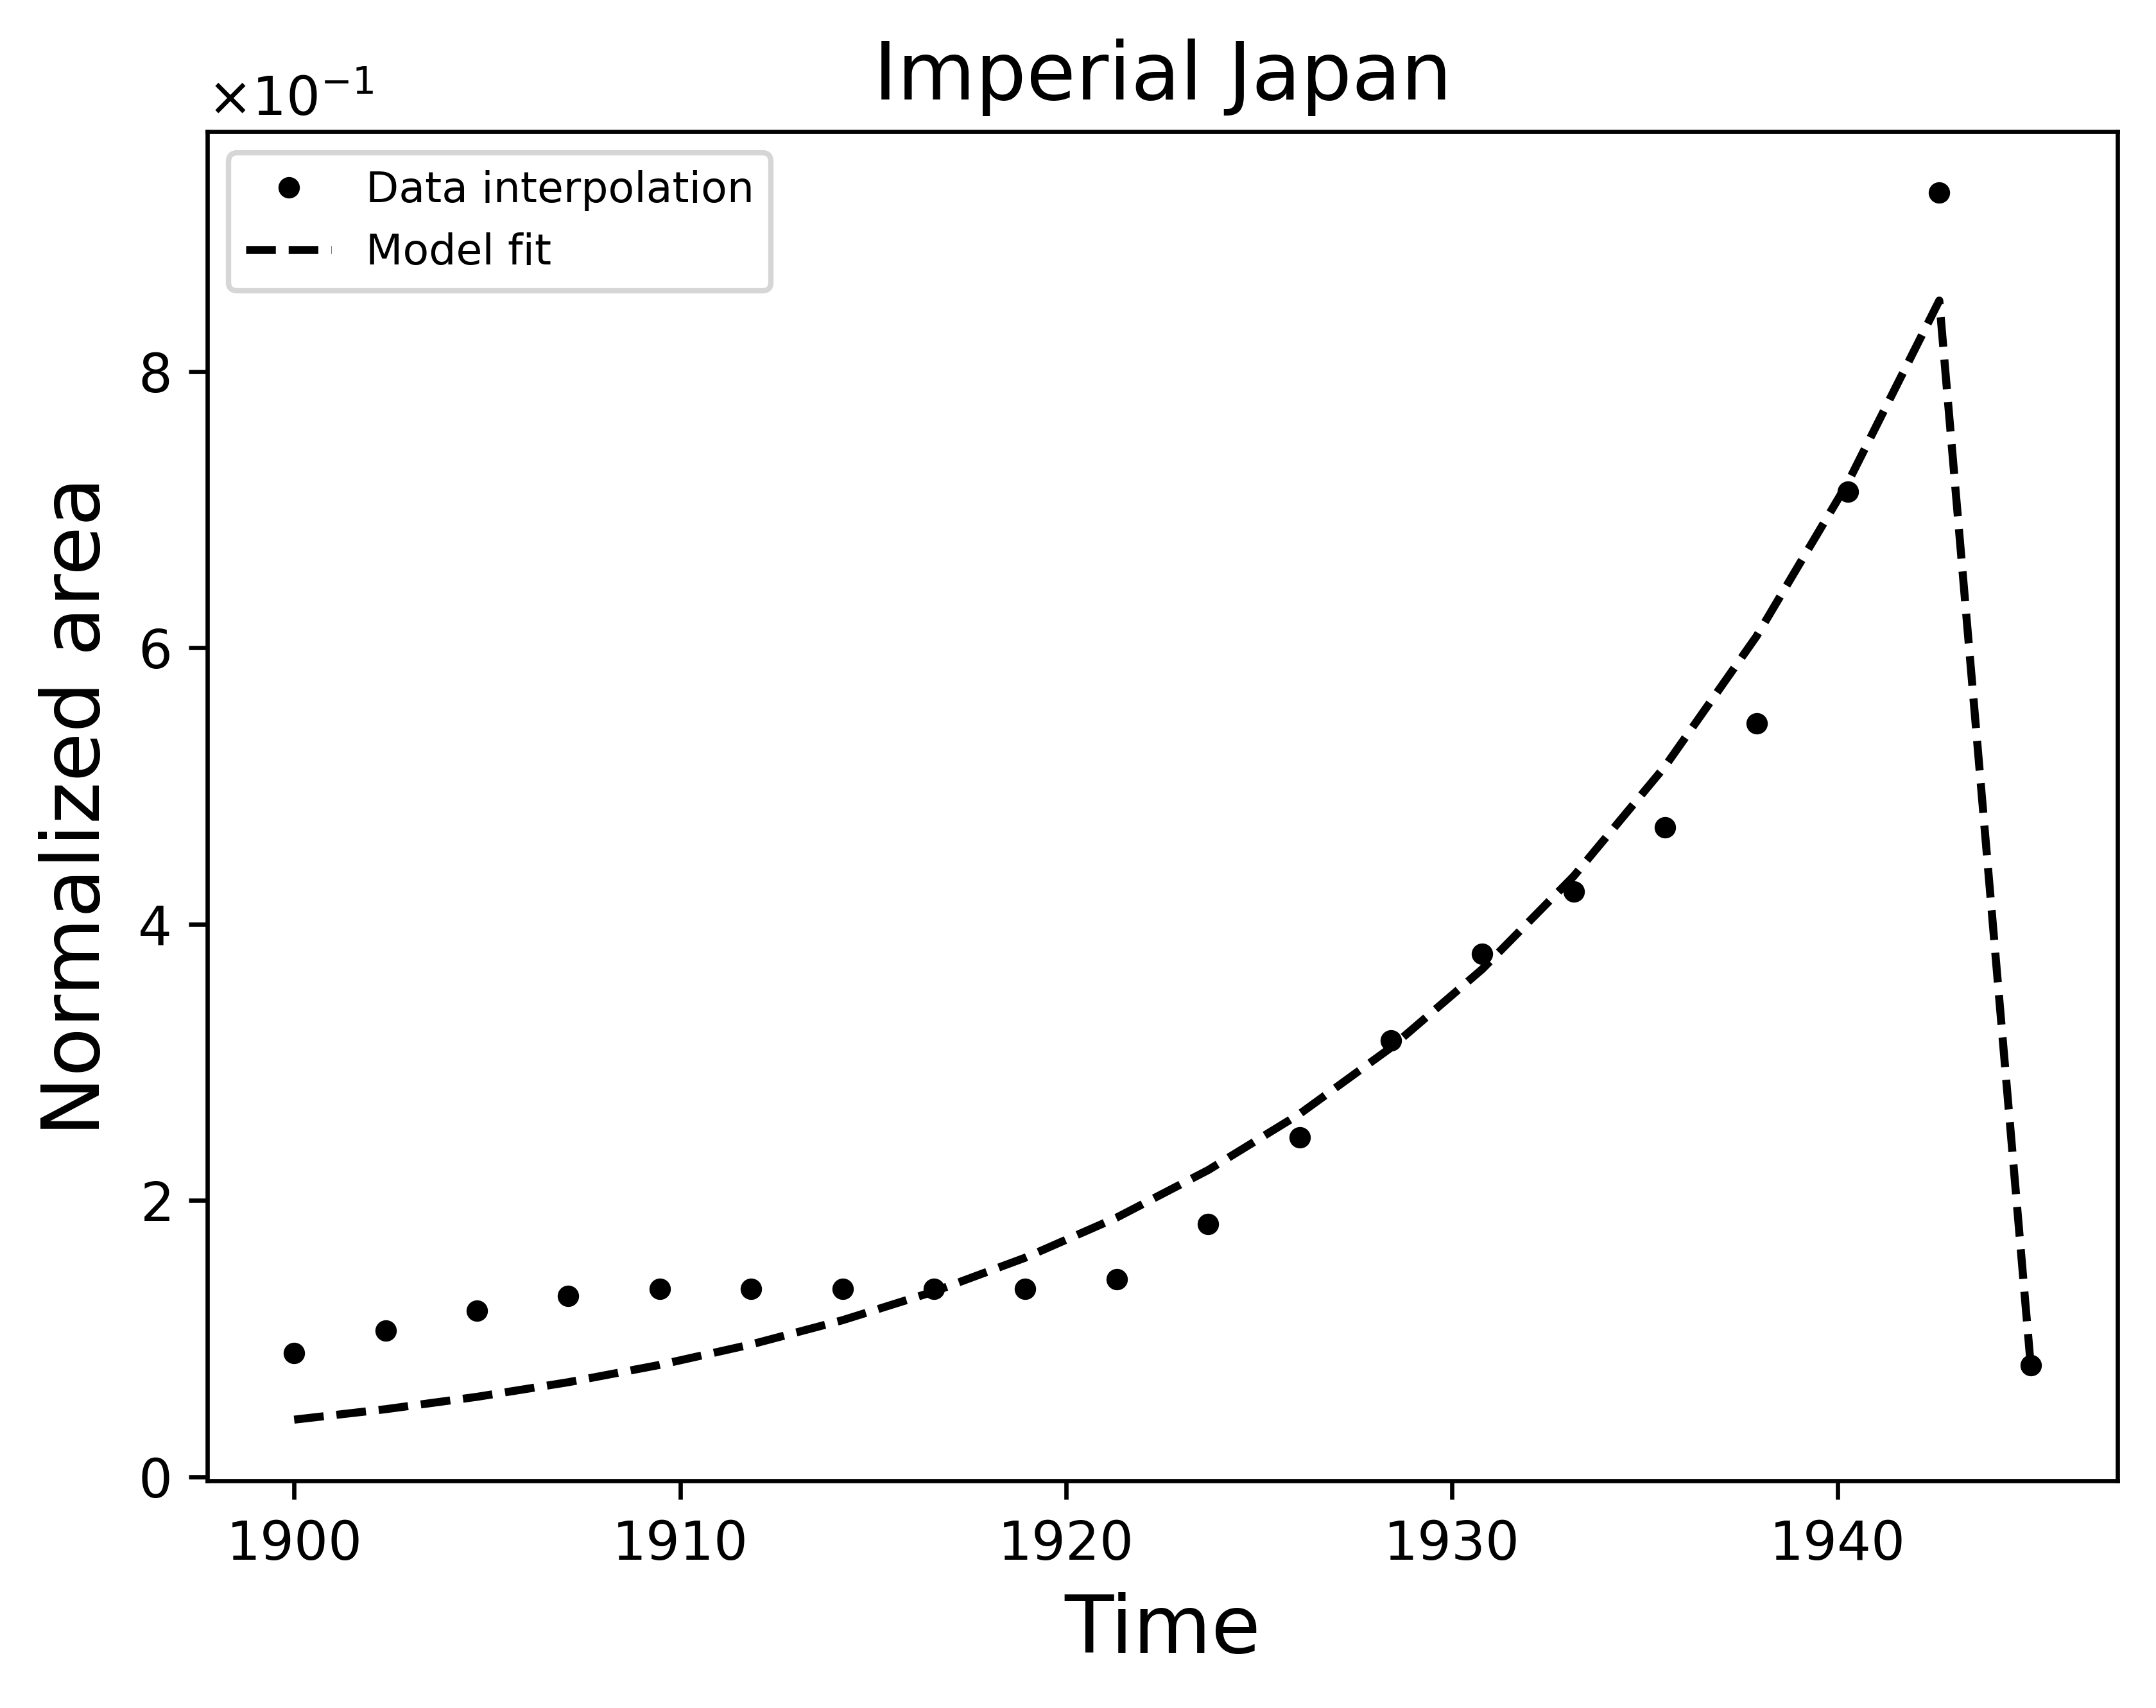

In [11]:
x0_jpn = [1., 1., 1., 1.942e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=10,
    x0=x0_jpn,
    save=True
)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.07555647384641251
        x: [ 9.481e-01  9.936e-02  1.028e+00  1.811e+03]
      nit: 23
      jac: [-4.230e-06  9.449e-06  8.028e-07  1.485e-06]
 hess_inv: [[ 5.211e-01 -8.603e-02  1.338e+00  1.259e+00]
            [-8.603e-02  3.354e-01 -2.675e+00 -2.608e+00]
            [ 1.338e+00 -2.675e+00  2.285e+01  2.218e+01]
            [ 1.259e+00 -2.608e+00  2.218e+01  2.632e+01]]
     nfev: 130
     njev: 26


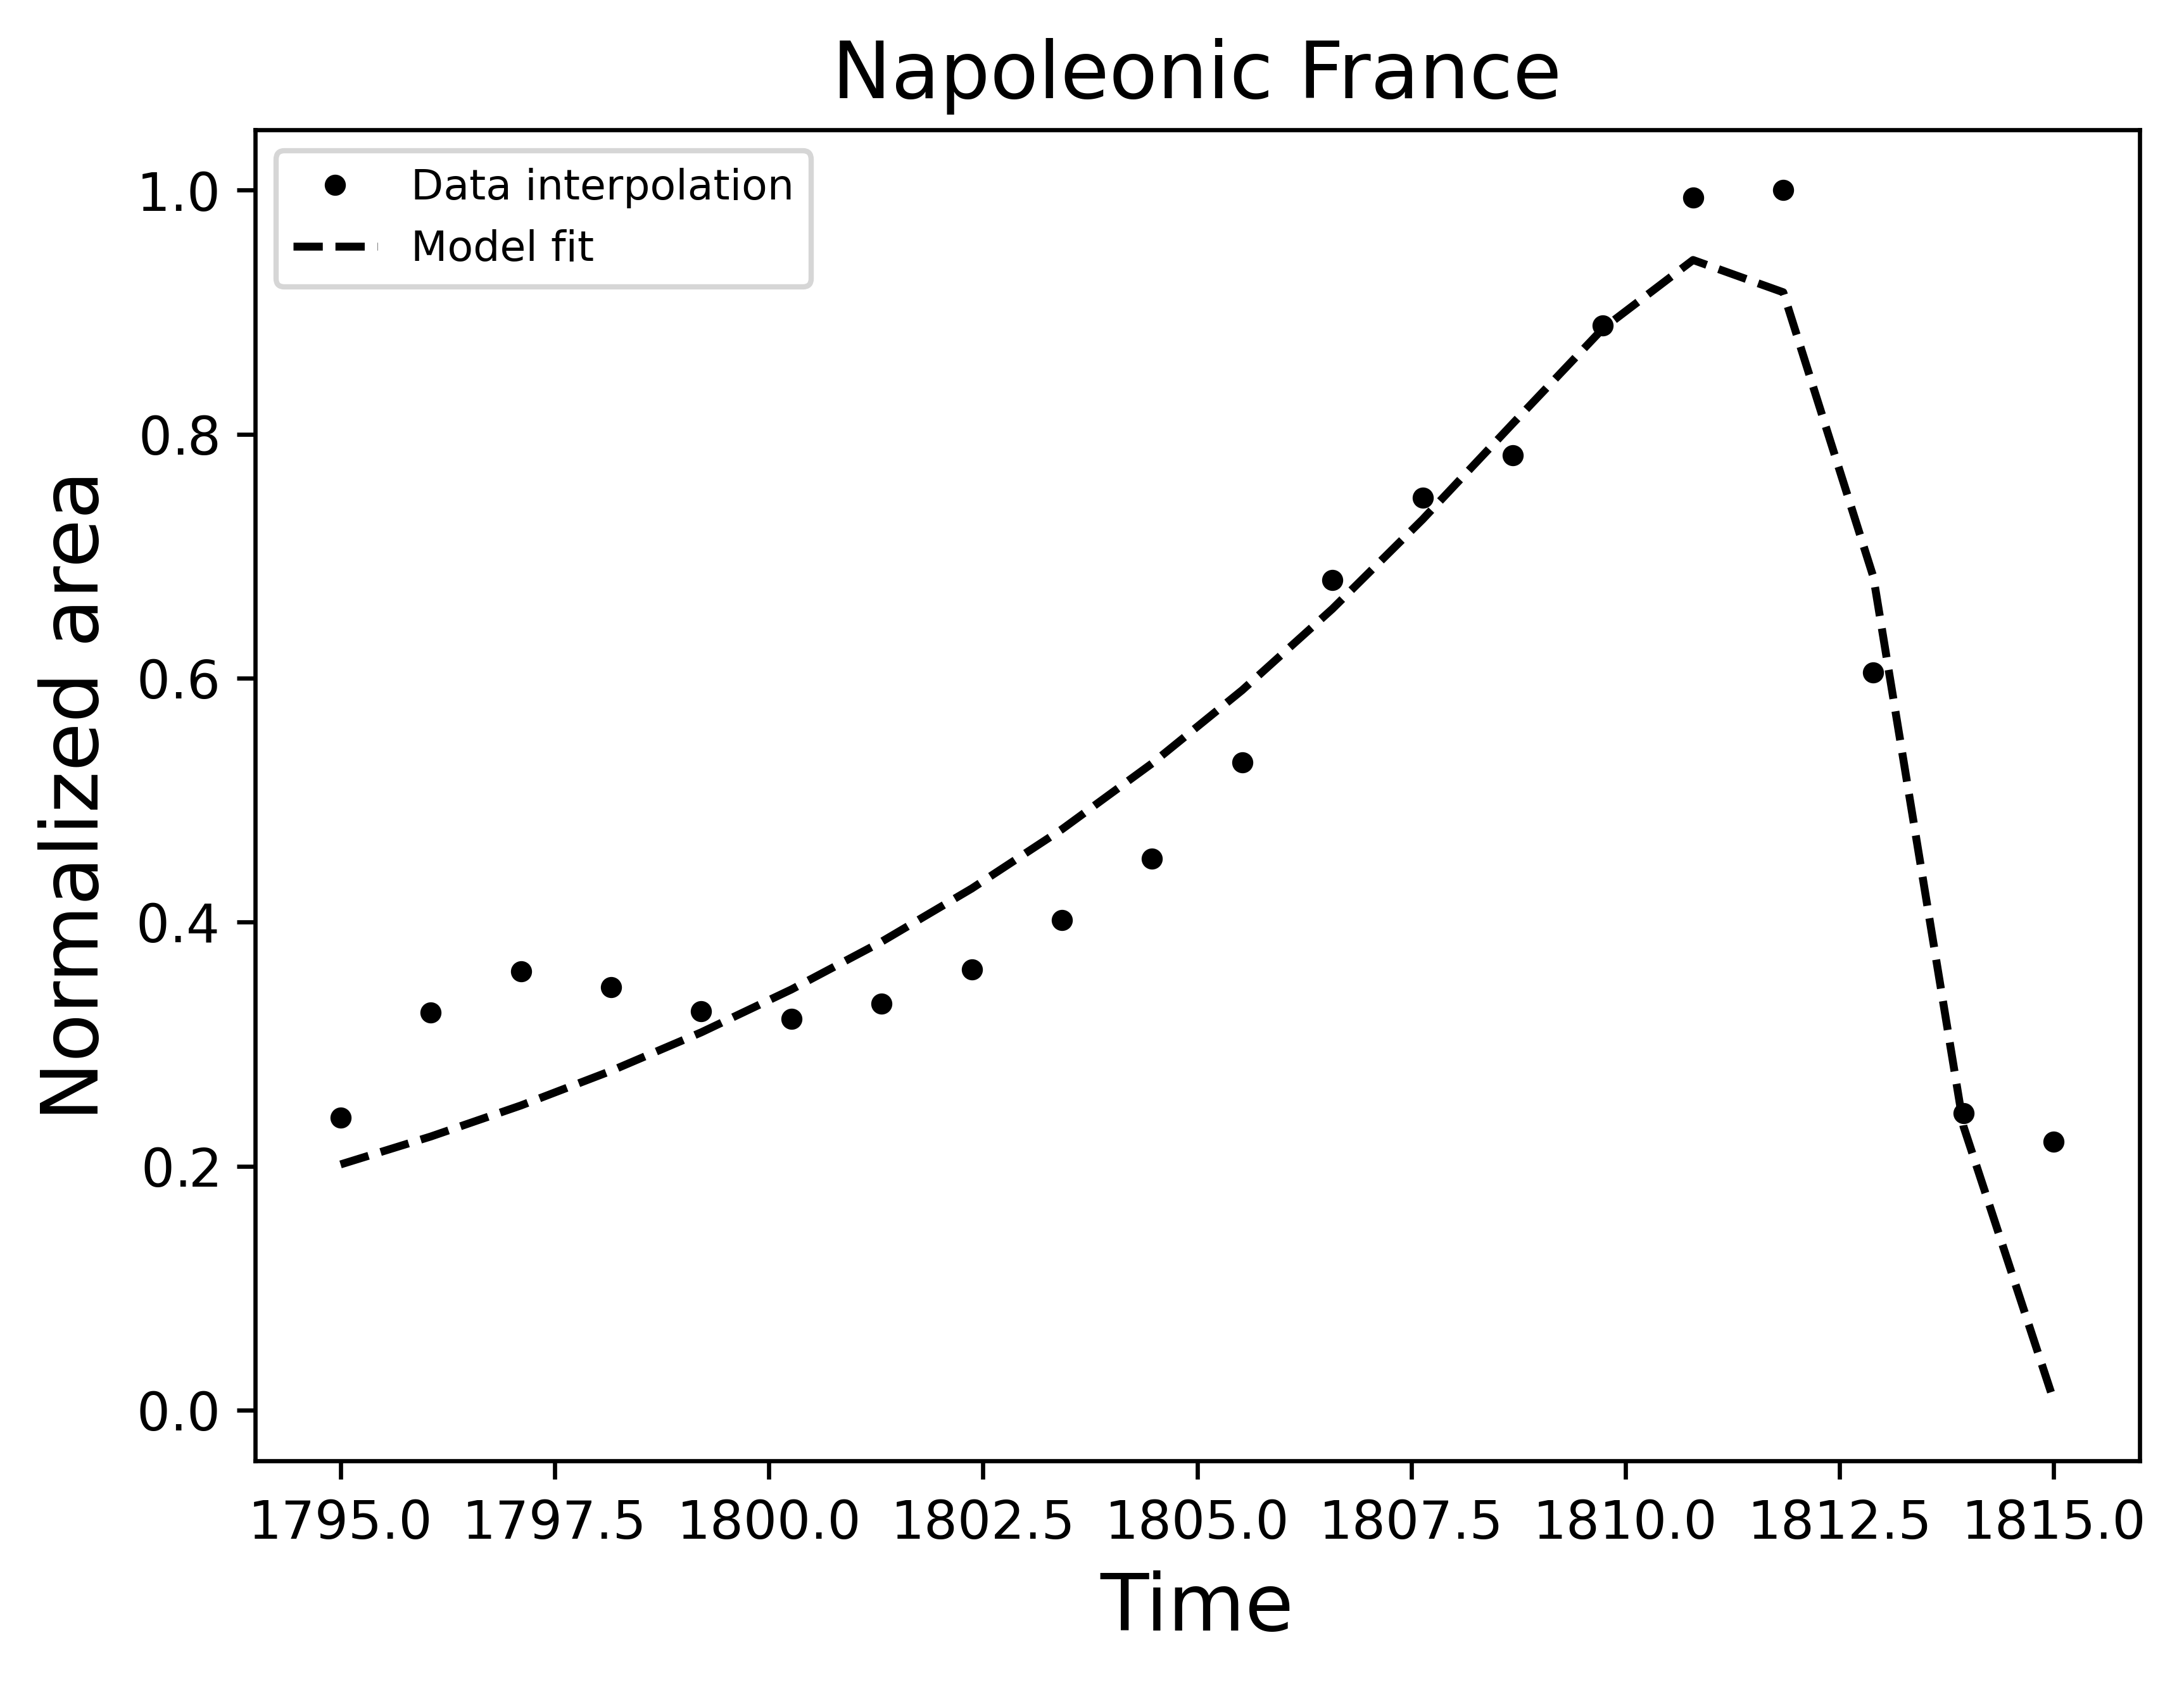

In [12]:
x0_nap = [1.02e+00, 2.0e-01, 3.0e-01, 1.811e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=11,
    x0=x0_nap,
    save=True
)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.08210489604823076
        x: [ 1.099e+00  6.763e-02  4.275e-01  1.935e+03]
      nit: 122
      jac: [-9.537e-07  5.584e-06  2.608e-07  9.965e-08]
 hess_inv: [[ 4.669e-01 -4.222e-02  4.038e-01  4.201e+00]
            [-4.222e-02  1.469e-01 -7.406e-01 -7.130e+00]
            [ 4.038e-01 -7.406e-01  3.899e+00  3.769e+01]
            [ 4.201e+00 -7.130e+00  3.769e+01  3.928e+02]]
     nfev: 810
     njev: 162


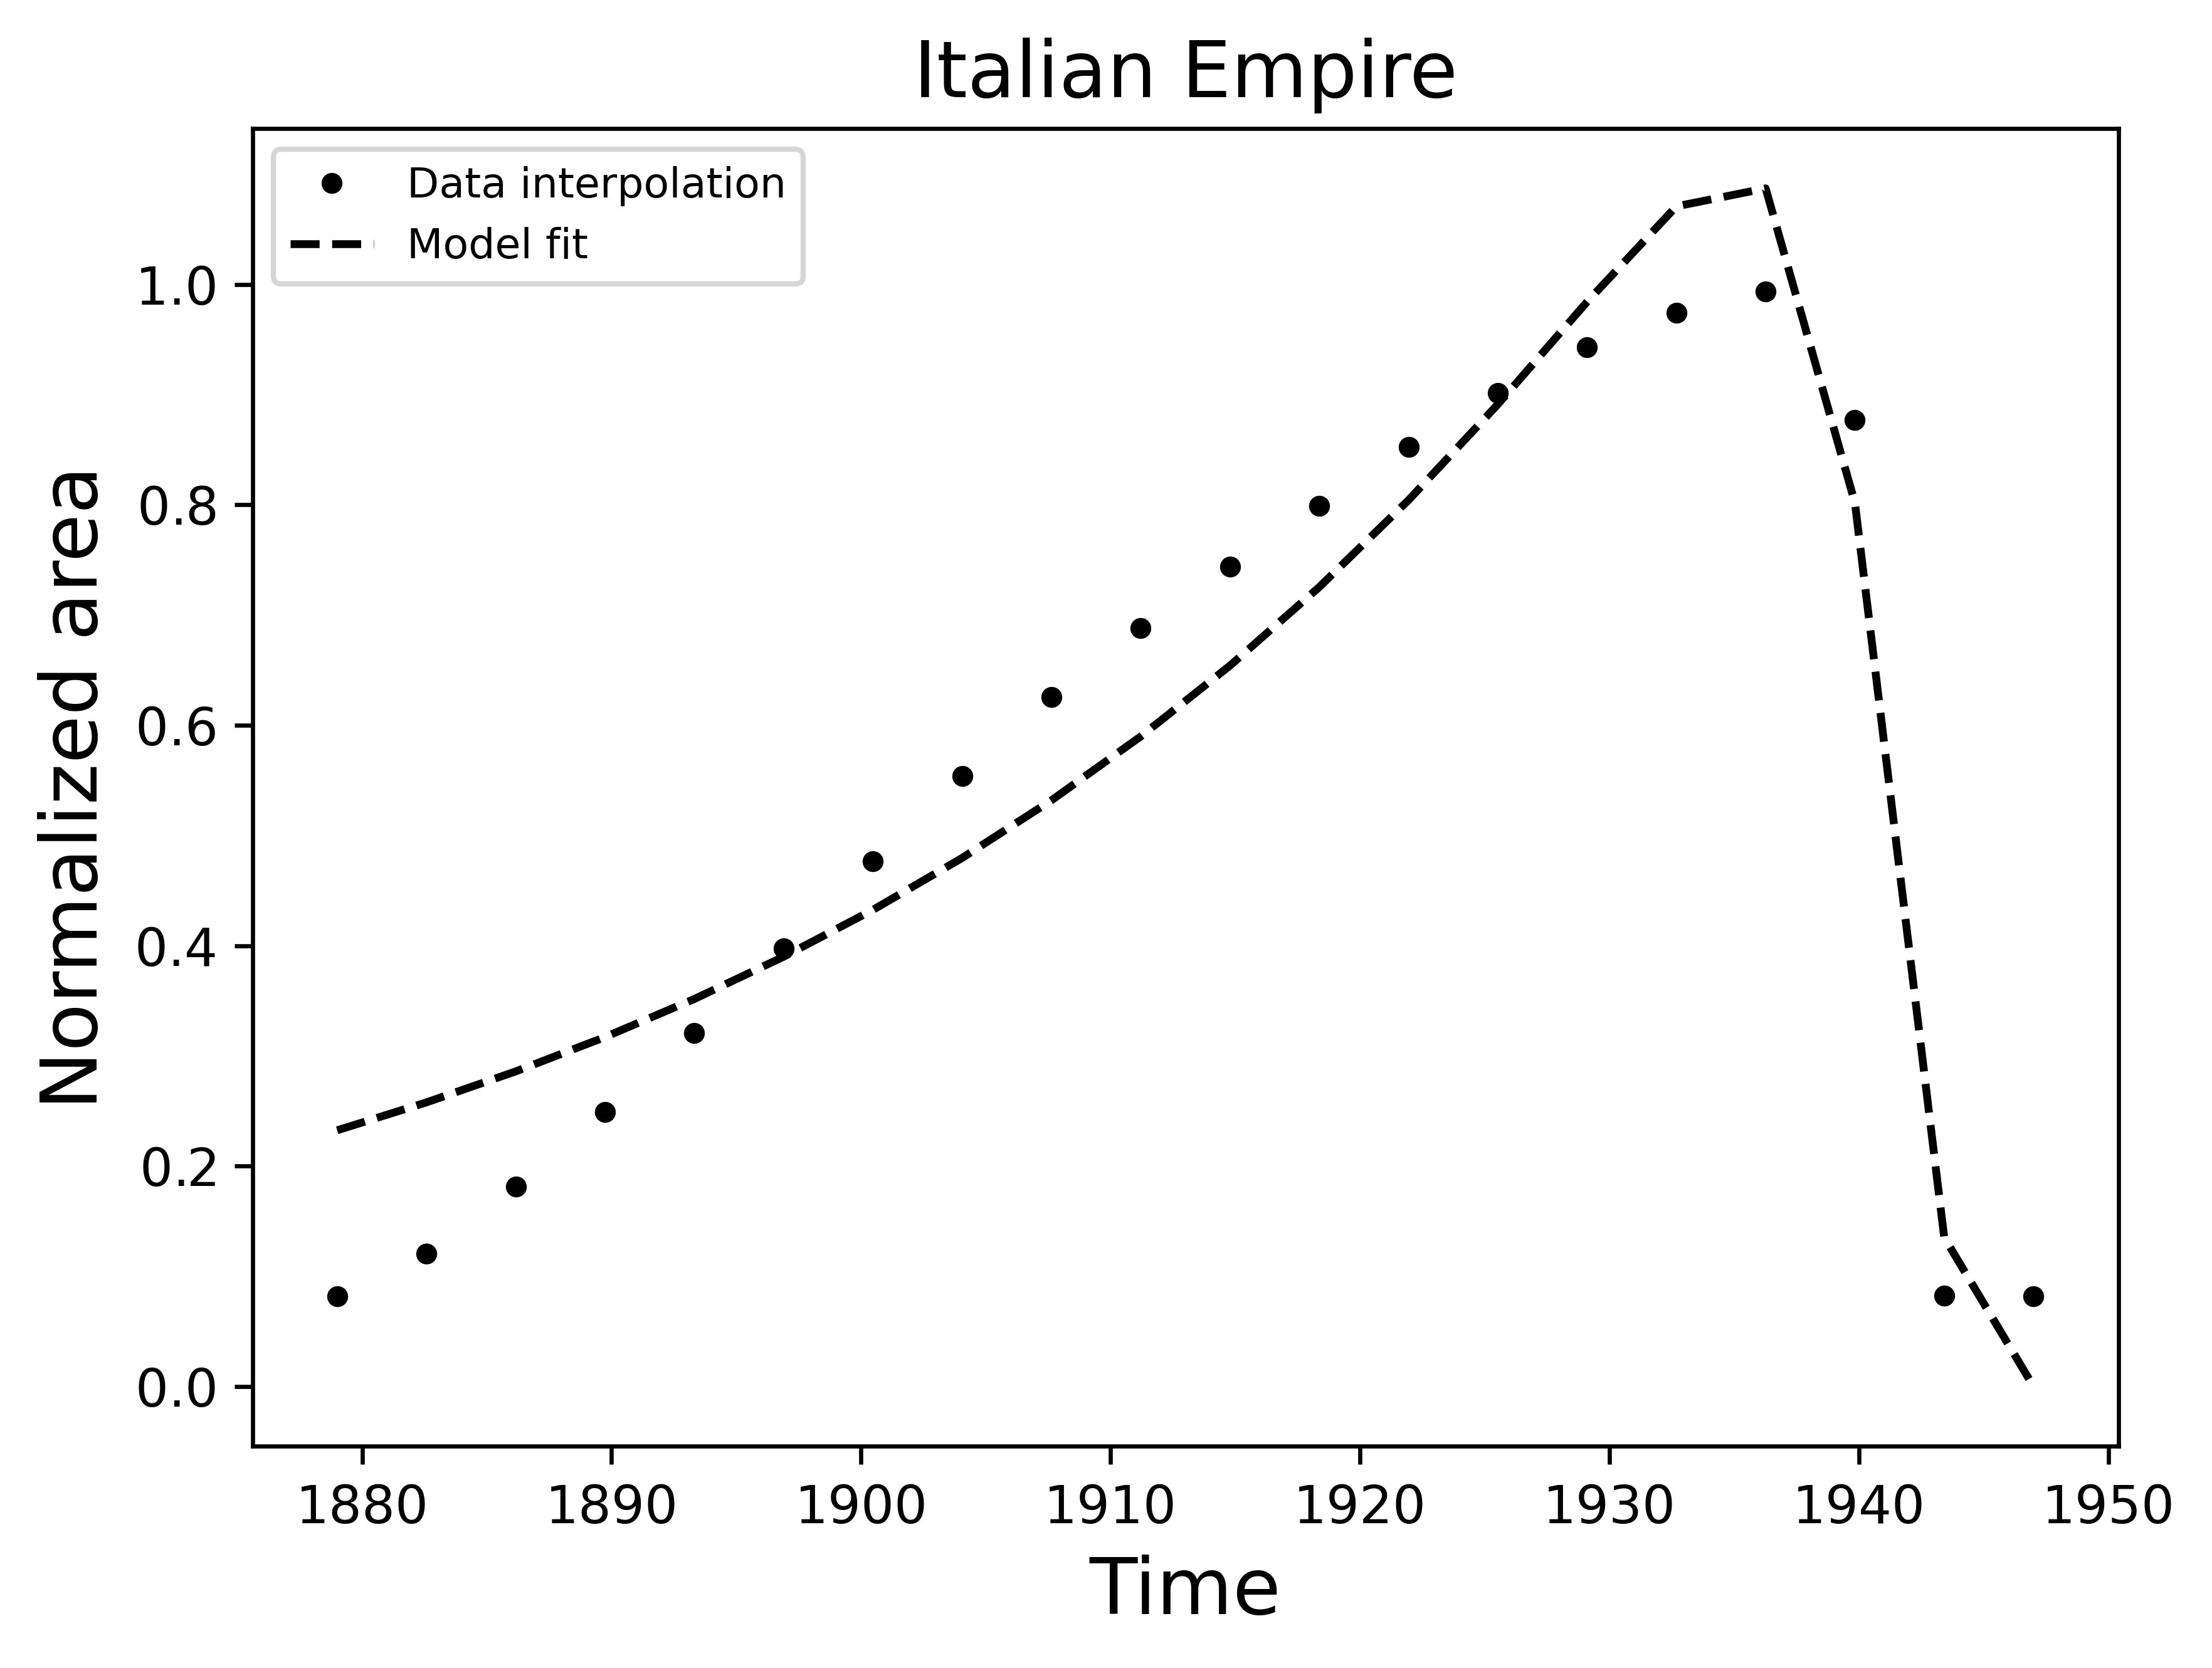

In [13]:
x0_ita = [1., 1e2, 1e-2, 1.940e+03]

result = fit_and_plot_case_from_csv(
    csv_file="normalized_interpolations.csv",
    k=12,
    x0=x0_ita,
    save=True
)